# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from plotly import express as px
import plotly.figure_factory as ff

from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import IsolationForest
from umap import UMAP

from sklearn.linear_model import LinearRegression
import sklearn
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import *

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import StackingRegressor
import optuna

# !pip install "kaleido==0.1.0.post1"

SEED = 17
compare_metric_name = "RMSLE"
N_TRIALS = 100
METRICS: dict[str, callable] = {
    "Accuracy": accuracy_score,
    "Balanced Accuracy": balanced_accuracy_score,
    "F1": f1_score,
    "Recall": recall_score,
    "Precision": precision_score,
    "Roc AUC": roc_auc_score,
    "MAE": mean_absolute_error,
    "MSE": mean_squared_error,
    "RMSE": mean_squared_error,
    "RMSLE": root_mean_squared_log_error,
    "R2": r2_score,
}

# Utility functions

In [2]:
def base_information(data):
    df =  pd.DataFrame(data.dtypes, columns=['dtypes'])
    df['Number of missing values'] = data.isna().sum()
    df['Percentage of missing values'] = data.isna().sum()/data.shape[0]
    df['Unique values'] = data.nunique().values
    df['Count'] = data.count().values
    return df.style.background_gradient(cmap='Blues')

In [3]:
def postprocess_predictions(y_pred: np.ndarray, min_value: float = 0, max_value: float = None) -> np.ndarray:
    """
    Postprocess predictions to ensure they are within specified bounds.
    
    Args:
        y_pred (np.ndarray): Predicted values.
        min_value (float, optional): Minimum value for predictions. Defaults to 0.
        max_value (float, optional): Maximum value for predictions. Defaults to None.
    
    Returns:
        np.ndarray: Postprocessed predictions.
    """
    if max_value is not None:
        y_pred = np.clip(y_pred, a_min=min_value, a_max=max_value)
    else:
        y_pred = np.clip(y_pred, a_min=min_value)
    return y_pred

def perform_cv(X: pd.DataFrame, y: pd.Series, algorithm: object, cv: sklearn.model_selection = KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name: str = "RMSE") -> tuple[list[float], list[float]]:
    """
    Perform cross-validation and return list of scores
    
    Args:
        X (pd.DataFrame): input data
        y (pd.Series): target data
        algorithm (Any): algorithm to use for training and prediction
        cv (sklearn.model_selection, default=KFold(n_splits=5, shuffle=True, random_state=SEED)): cross-validation strategy
        metric_name (str, default="RMSE"): metric name to use for evaluation
    
    Returns:
        tuple[list[float], list[float]]: Tuple of lists of train and validation scores
    """
    if metric_name not in METRICS:
        raise ValueError(f"Metric {metric_name} not found in METRICS dictionary")
    metric = METRICS[metric_name]
    train_scores, validation_scores = [], []
    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        algorithm.fit(X_train, y_train)
        y_train_pred = algorithm.predict(X_train)
        y_valid_pred = algorithm.predict(X_valid)
        y_train_pred = postprocess_predictions(y_train_pred, min_value=1, max_value=314)
        y_valid_pred = postprocess_predictions(y_valid_pred, min_value=1, max_value=314)
        train_scores.append(metric(y_train, y_train_pred))
        validation_scores.append(metric(y_valid, y_valid_pred))
    return train_scores, validation_scores

In [4]:
class Plots:
    def __init__(self):
        self.quantiles_dict = {"Min": 0, "Q1": 0.25, "Med": 0.5, "Q3": 0.75, "Max": 1}

    def check_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        data = np.array(data)
        data = data[~np.isnan(data)]
        if(data.ndim == 2):
            data = data.squeeze()
        return data
    
    def check_2d_data(self, data):
        if not isinstance(data, pd.DataFrame) and not isinstance(data, pd.Series) and not isinstance(data, np.ndarray):
            raise TypeError('Wrong type of data. It should be pandas DataFrame, pandas Series, numpy array')
        return np.array(data)
    
    def histogram_and_box_plot(self, data, name="", annotations=True, bin_size=1):
        data = self.check_data(data=data)
        fig = make_subplots(rows=1, cols=2, specs=[[{"type": "histogram"}, {"type": "box"}]])
        fig.add_trace(go.Box(y=data, name='', marker=dict(color="rgb(48,70,116)"), showlegend=False), row=1, col=1)
        fig.add_trace(go.Histogram(x=data, marker=dict(color="rgb(48,70,116)"), showlegend=False, xbins=dict(size=bin_size)), row=1, col=2)
        if type(annotations) == list:
            for x in annotations:
                fig.add_annotation(x=0.4, y=np.quantile(data, self.quantiles_dict[x]), text=x + ": " + str(np.round(np.quantile(data, self.quantiles_dict[x]), 3)), showarrow=False)
        elif type(annotations) == bool:
            if annotations:
                for key, value in self.quantiles_dict.items():
                    fig.add_annotation(x=0.4, y=np.quantile(data, value), text=key + ": " + str(np.round(np.quantile(data, value), 3)), showarrow=False)
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def histogram_boxplot_linear_regression(self, data, feature, target, name="", annotations=True, bin_size=1):
        model = LinearRegression()
        no_nan_indices = ~data[feature].isna()
        model.fit(data[no_nan_indices][feature].values.reshape(-1, 1), data[no_nan_indices][target])
        predictions = model.predict(data[no_nan_indices][feature].values.reshape(-1, 1))
        fig = make_subplots(rows=1, cols=3, specs=[[{"type": "histogram"}, {"type": "box"}, {"type": "scatter"}]])
        fig.add_trace(go.Box(y=data[no_nan_indices][feature], name='', marker=dict(color="rgb(48,70,116)"), showlegend=False), row=1, col=1)
        fig.add_trace(go.Histogram(x=data[no_nan_indices][feature], marker=dict(color="rgb(48,70,116)"), showlegend=False, xbins=dict(size=bin_size)), row=1, col=2)
        fig.add_trace(go.Scatter(x=data[no_nan_indices][feature], y=data[no_nan_indices][target], mode='markers', marker=dict(color="lightblue"), name='Real values', showlegend=False), row=1, col=3)
        fig.add_trace(go.Scatter(x=data[no_nan_indices][feature], y=predictions, mode='lines', line_color="green", name=feature, showlegend=False), row=1, col=3)
        fig.update_xaxes(title_text=feature, row=1, col=3)
        fig.update_yaxes(title_text=f"{target}", row=1, col=3)
        if type(annotations) == list:
            for x in annotations:
                fig.add_annotation(x=0.4, y=np.quantile(data[no_nan_indices][feature], self.quantiles_dict[x]), text=x + ": " + str(np.round(np.quantile(data[no_nan_indices][feature], self.quantiles_dict[x]), 3)), showarrow=False)
        elif type(annotations) == bool:
            if annotations:
                for key, value in self.quantiles_dict.items():
                    fig.add_annotation(x=0.4, y=np.quantile(data[no_nan_indices][feature], value), text=key + ": " + str(np.round(np.quantile(data[no_nan_indices][feature], value), 3)), showarrow=False)
        fig.update_layout(template="simple_white", width=2000, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def boxplot_by_categorical(self, data, categorical, target, name=""):
        data_copy = data.copy()
        data_copy.reset_index(drop=True, inplace=True)
        labels, frequency = np.array(data_copy[categorical].value_counts().index), np.array(data_copy[categorical].value_counts().values)
        sorted_indices = np.argsort(frequency)[::-1]
        labels = labels[sorted_indices]
        frequency = frequency[sorted_indices]
        colors = px.colors.qualitative.Dark24*20
        fig = go.Figure()
        for color_idx, category in enumerate(labels):
            indices = list(np.where(data_copy[categorical]==category)[0])
            grouped_data = list(data_copy[target][indices])
            fig.add_trace(go.Box(y=grouped_data, name=str(category), marker=dict(color=colors[color_idx]), showlegend=False))
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.update_yaxes(title_text=f"{target}", title_font=dict(size=16, color="Black"))
        fig.show("png")
    
    def pie_boxplot_by_categorical(self, data, categorical, target, name=""):
        data_copy = data.copy()
        data_copy.reset_index(drop=True, inplace=True)
        labels, frequency = np.array(data_copy[categorical].value_counts().index), np.array(data_copy[categorical].value_counts().values)
        sorted_indices = np.argsort(frequency)[::-1]
        labels = labels[sorted_indices]
        frequency = frequency[sorted_indices]
        colors = px.colors.qualitative.Dark24
        rows, columns = 1, 2
        fig = make_subplots(rows=rows, cols=columns, specs=[[{"type": "pie"}, {"type": "bar"}] for i in range(0, rows)])
        fig.add_trace(go.Pie(values=frequency, labels=labels, showlegend=True, textinfo='value+percent', hole=0.3, marker=dict(line=dict(color='black', width=2), colors=colors)), row=1, col=1)
        for color_idx, category in enumerate(labels):
            indices = list(np.where(data_copy[categorical]==category)[0])
            grouped_data = list(data_copy[target][indices])
            fig.add_trace(go.Box(y=grouped_data, name=str(category), marker=dict(color=colors[color_idx]), showlegend=False))
        fig.update_layout(template="simple_white", width=1600, height=800, title=f"<b>{name.title()} distribution<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def correlation_plot(self, data, features_names, method="spearman"):
        data = self.check_2d_data(data=data)
        data = pd.DataFrame(data, columns=features_names)
        corr = np.round(data[data.columns.tolist()].corr(method=method), 3)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        data_mask = corr.mask(mask)
        fig = ff.create_annotated_heatmap(z=data_mask.to_numpy(), x=data_mask.columns.tolist(), y=data_mask.columns.tolist(), colorscale=px.colors.diverging.RdBu,hoverinfo="none", showscale=True, ygap=1, xgap=1)
        fig.update_xaxes(side="bottom")
        fig.update_layout(width=1500, height=1500, xaxis_showgrid=False,yaxis_showgrid=False,xaxis_zeroline=False,yaxis_zeroline=False,yaxis_autorange='reversed',template='plotly_white',font=dict(family="Times New Roman",size=20,color="Black"))
        for i in range(len(fig.layout.annotations)):
            if fig.layout.annotations[i].text == 'nan':
                fig.layout.annotations[i].text = ""
        fig.show("png")
    
    def scatter_plot(self, data, hue, hue_name, name=""):
        data = np.array(data)
        hue = np.array(hue).squeeze()
        fig = go.Figure()
        unique_hues = np.unique(hue)
        for unique_hue in unique_hues:
            fig.add_trace(go.Scatter(x=data[hue == unique_hue, 0], y=data[hue == unique_hue, 1], mode='markers', marker=dict(showscale=False), name=str(unique_hue)))
        fig.update_xaxes(title_text="Component 1")
        fig.update_yaxes(title_text="Component 2")
        fig.update_layout(template="simple_white", width=1000, height=1000, title=f"<b>{name}<b>", title_x=0.5, font=dict(family="Times New Roman", size=26, color="Black"), legend_title_text=hue_name, legend_title_font=dict(size=26, color="Black"), legend_font=dict(size=20, color="Black"))
        fig.show("png")

    def homoscedacity_plot(self, y_true, y_pred, metric="rmse"):
        if metric not in METRICS:
            raise ValueError('Unsupported metric: {}'.format(metric))
        eval_metric = METRICS[metric](y_true, y_pred)
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        residuals = y_true - y_pred
        fig = px.scatter(x=y_pred, y=residuals, labels={"x": "Fitted values",  "y": "Residuals"})
        fig.add_shape(type="line", line_color="red", line_width=2, opacity=0.5, line_dash="dash",x0=0, x1=1, xref="paper", y0=0, y1=0, yref="y")
        fig.update_layout(template="simple_white", width=1200, height=1000, title=f"<b>Homoscedacity plot ({metric.upper()}: {eval_metric:.4f})<b>", title_x=0.5, xaxis_title="Fitted values", yaxis_title="Residuals", font=dict(family="Times New Roman",size=16,color="Black"))
        fig.show("png")
    
    def true_vs_fitted_plot(self, y_true, y_pred, metric="RMSE"):
        if metric not in METRICS:
            raise ValueError('Unsupported metric: {}'.format(metric))
        eval_metric = METRICS[metric](y_true, y_pred)
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        fig = px.scatter(x=y_pred, y=y_true, labels={"x": "Fitted values",  "y": "True values"}, trendline="ols", trendline_color_override="green")
        fig.data[1].line.width = 8
        fig.update_layout(template="simple_white", width=1200, height=1000, xaxis_title="Fitted values", yaxis_title="True values", title=f"<b>True vs Fitted plot ({metric.upper()}: {eval_metric:.4f})<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
        fig.update_xaxes(range=[np.min(y_pred) - 0.01 * np.min(y_pred), np.max(y_pred) + 0.01 * np.max(y_pred)])
        fig.update_yaxes(range=[np.min(y_true) - 0.01 * np.min(y_true), np.max(y_true) + 0.01 * np.max(y_true)])
        fig.show("png")
    
plots = Plots()

# Load dataset

In [5]:
train_data = pd.read_csv('input/train.csv')
test_data = pd.read_csv('input/test.csv')
train_data = train_data[:10000]
target_feature = 'Calories'
train_data

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
9995,9995,female,36,167.0,64.0,26.0,108.0,40.8,166.0
9996,9996,male,46,199.0,103.0,17.0,104.0,40.2,112.0
9997,9997,female,35,158.0,61.0,19.0,99.0,40.4,103.0
9998,9998,female,29,148.0,53.0,2.0,80.0,38.1,6.0


In [6]:
base_information(train_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
id,int64,0,0.000000,10000,10000
Sex,object,0,0.000000,2,10000
Age,int64,0,0.000000,60,10000
Height,float64,0,0.000000,71,10000
Weight,float64,0,0.000000,69,10000
Duration,float64,0,0.000000,30,10000
Heart_Rate,float64,0,0.000000,53,10000
Body_Temp,float64,0,0.000000,43,10000
Calories,float64,0,0.000000,267,10000


In [7]:
base_information(test_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
id,int64,0,0.000000,250000,250000
Sex,object,0,0.000000,2,250000
Age,int64,0,0.000000,60,250000
Height,float64,0,0.000000,85,250000
Weight,float64,0,0.000000,84,250000
Duration,float64,0,0.000000,30,250000
Heart_Rate,float64,0,0.000000,61,250000
Body_Temp,float64,0,0.000000,51,250000


# Initial cleaning

In [8]:
def initial_columns_removal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove features that are not useful for the model:
        - 1 unique value (variance = 0)
        - all missing values
        - duplicated columns
    
    Args:
        df (pd.DataFrame): DataFrame to be cleaned.
    
    Returns:
        pd.DataFrame: Cleaned DataFrame.
    """
    number_of_columns_before = df.shape[1]
    df = df.loc[:, df.nunique() > 1]
    df = df.dropna(axis=1, how='all')
    df = df.loc[:, ~df.columns.duplicated()]
    print(f"Removed {number_of_columns_before - df.shape[1]} columns.")
    return df.reset_index(drop=True)

train_data = initial_columns_removal(train_data)

Removed 0 columns.


# Features exploration

## `id`

`id` is a unique identifier for each record. It is not useful for analysis, so it will be dropped.

In [9]:
train_data.drop("id", axis=1, inplace=True)
test_data.drop("id", axis=1, inplace=True)

## `Sex`

`Sex` is a categorical variable with two values: `male` and `female`.

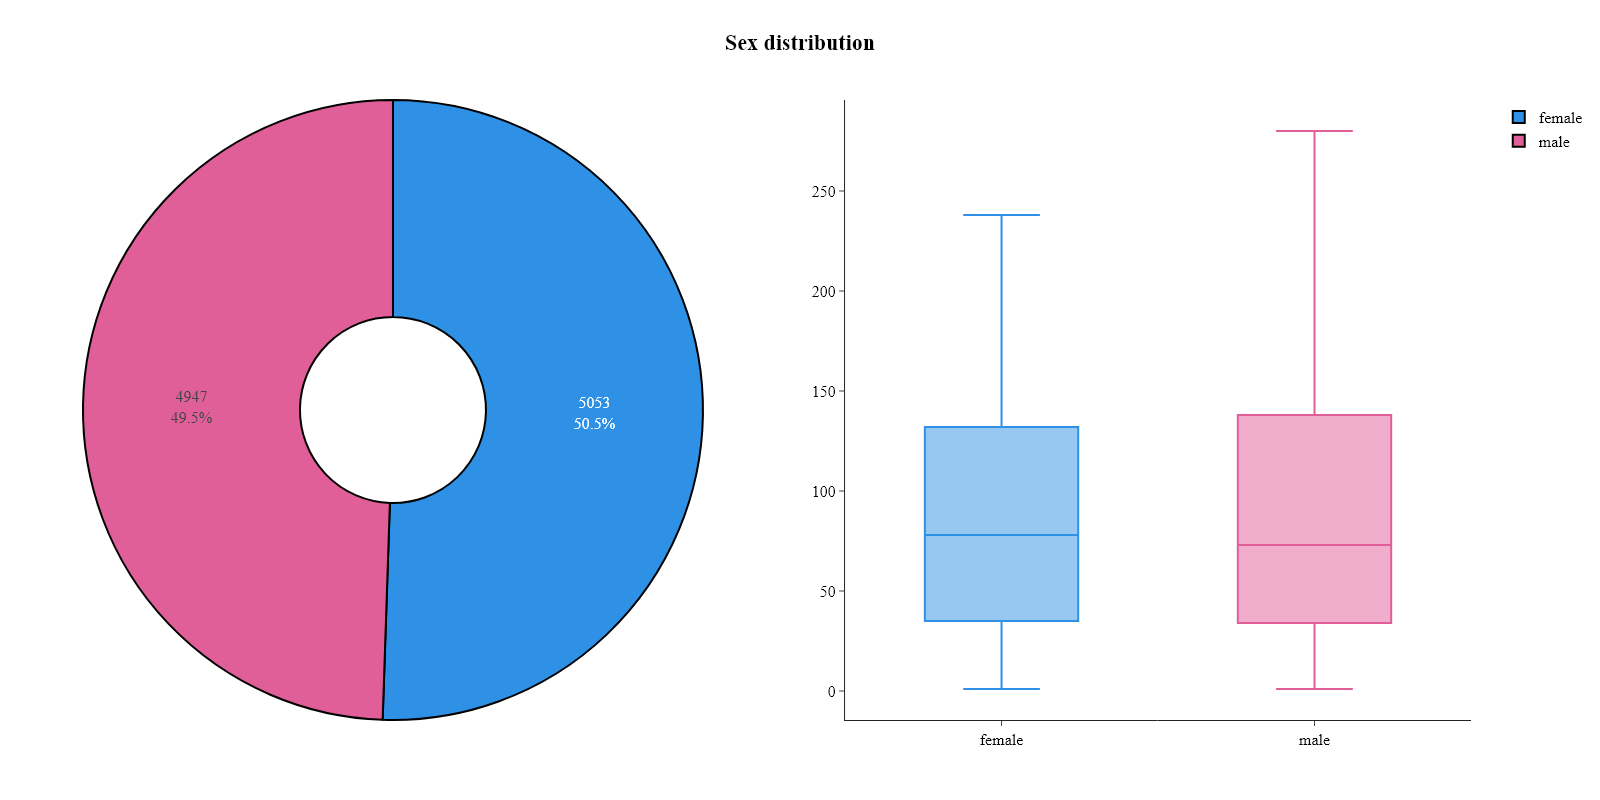

In [10]:
plots.pie_boxplot_by_categorical(train_data, "Sex", target_feature, "Sex")

**Notes:**
- Distribution of target variable is similar across both males and females.

**Conclusion:**
- I will convert the column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [11]:
train_data['Sex'] = train_data['Sex'].astype('category')
test_data['Sex'] = test_data['Sex'].astype('category')

## `Age`

`Age` is a continuous variable representing the age of the passenger in years.

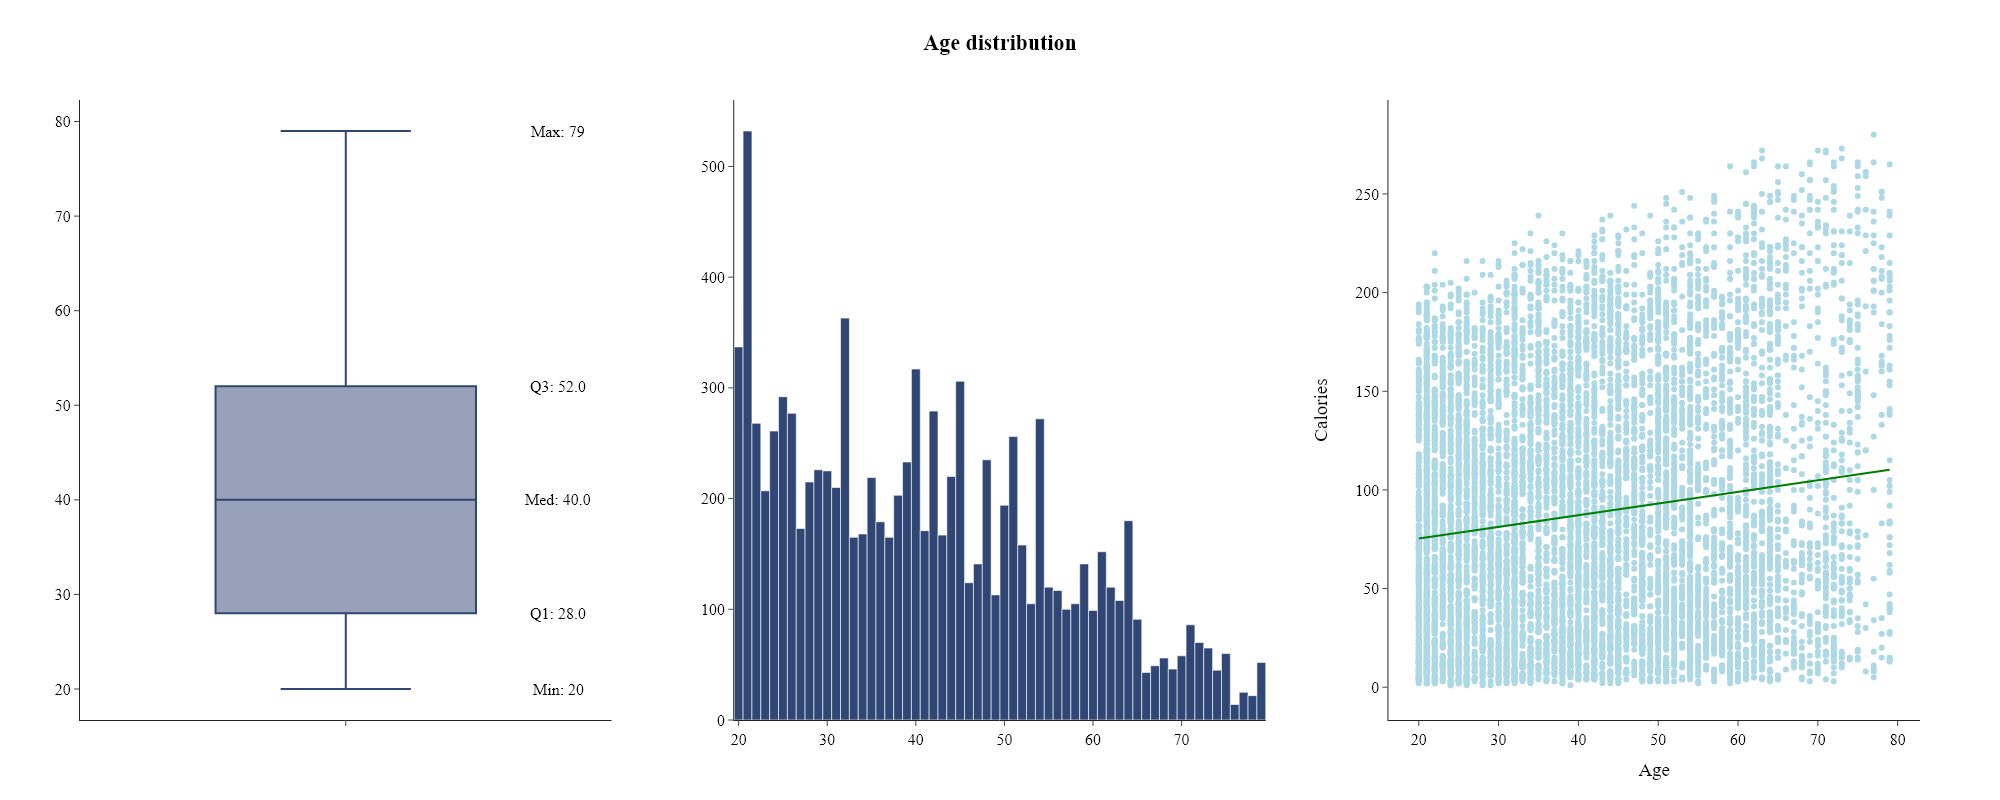

In [12]:
plots.histogram_boxplot_linear_regression(train_data, "Age", target_feature, "Age")

**Notes:**
- Age distribution is right-skewed with a long tail.
- With the increase in age, the calorie burn rate also increases.

**Conclusion:**
- I will create a new feature `AgeGroup` to categorize passengers into age groups. This will help in understanding the impact of age on calorie burn rate.

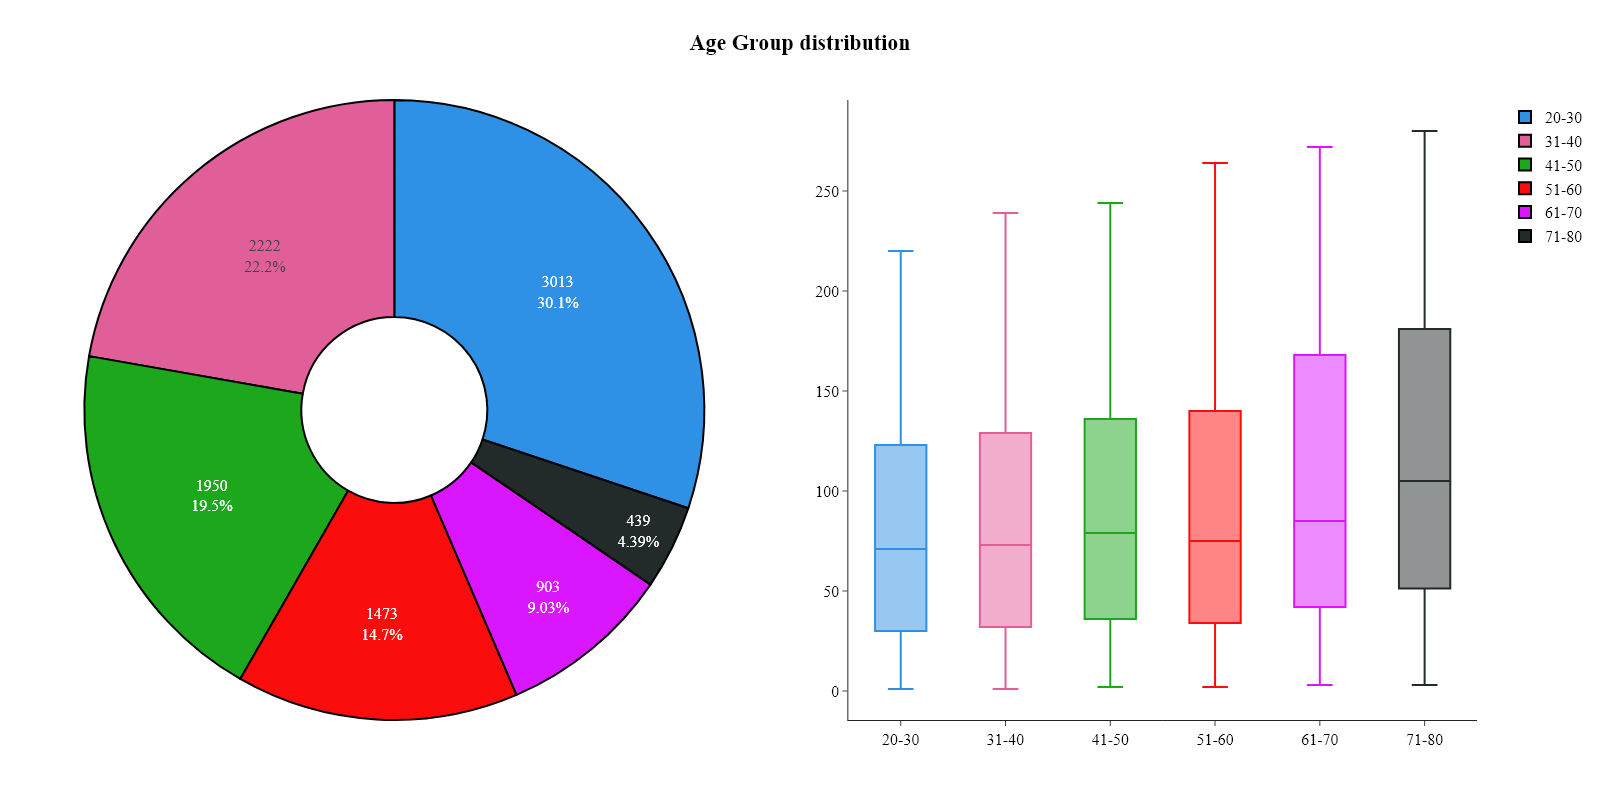

In [13]:
train_data["Age_Group"] = pd.cut(train_data["Age"], bins=[19, 30, 40, 50, 60, 70, 80], labels=["20-30", "31-40", "41-50", "51-60", "61-70", "71-80"])
test_data["Age_Group"] = pd.cut(test_data["Age"], bins=[19, 30, 40, 50, 60, 70, 80], labels=["20-30", "31-40", "41-50", "51-60", "61-70", "71-80"])
plots.pie_boxplot_by_categorical(train_data, "Age_Group", target_feature, "Age Group")

**Notes:**
- Thanks to converting `Age` into `AgeGroup`, we can clearly see that the calorie burn rate is higher in older age groups.

**Conclusion:**
- I will convert the `AgeGroup` column to `category` dtype as it is a categorical variable (converting to `category` dtype reduces memory usage).

In [14]:
train_data['Age_Group'] = train_data['Age_Group'].astype('category')
test_data['Age_Group'] = test_data['Age_Group'].astype('category')

## `Height`

`Height` is a continuous variable representing the height of person in cm.

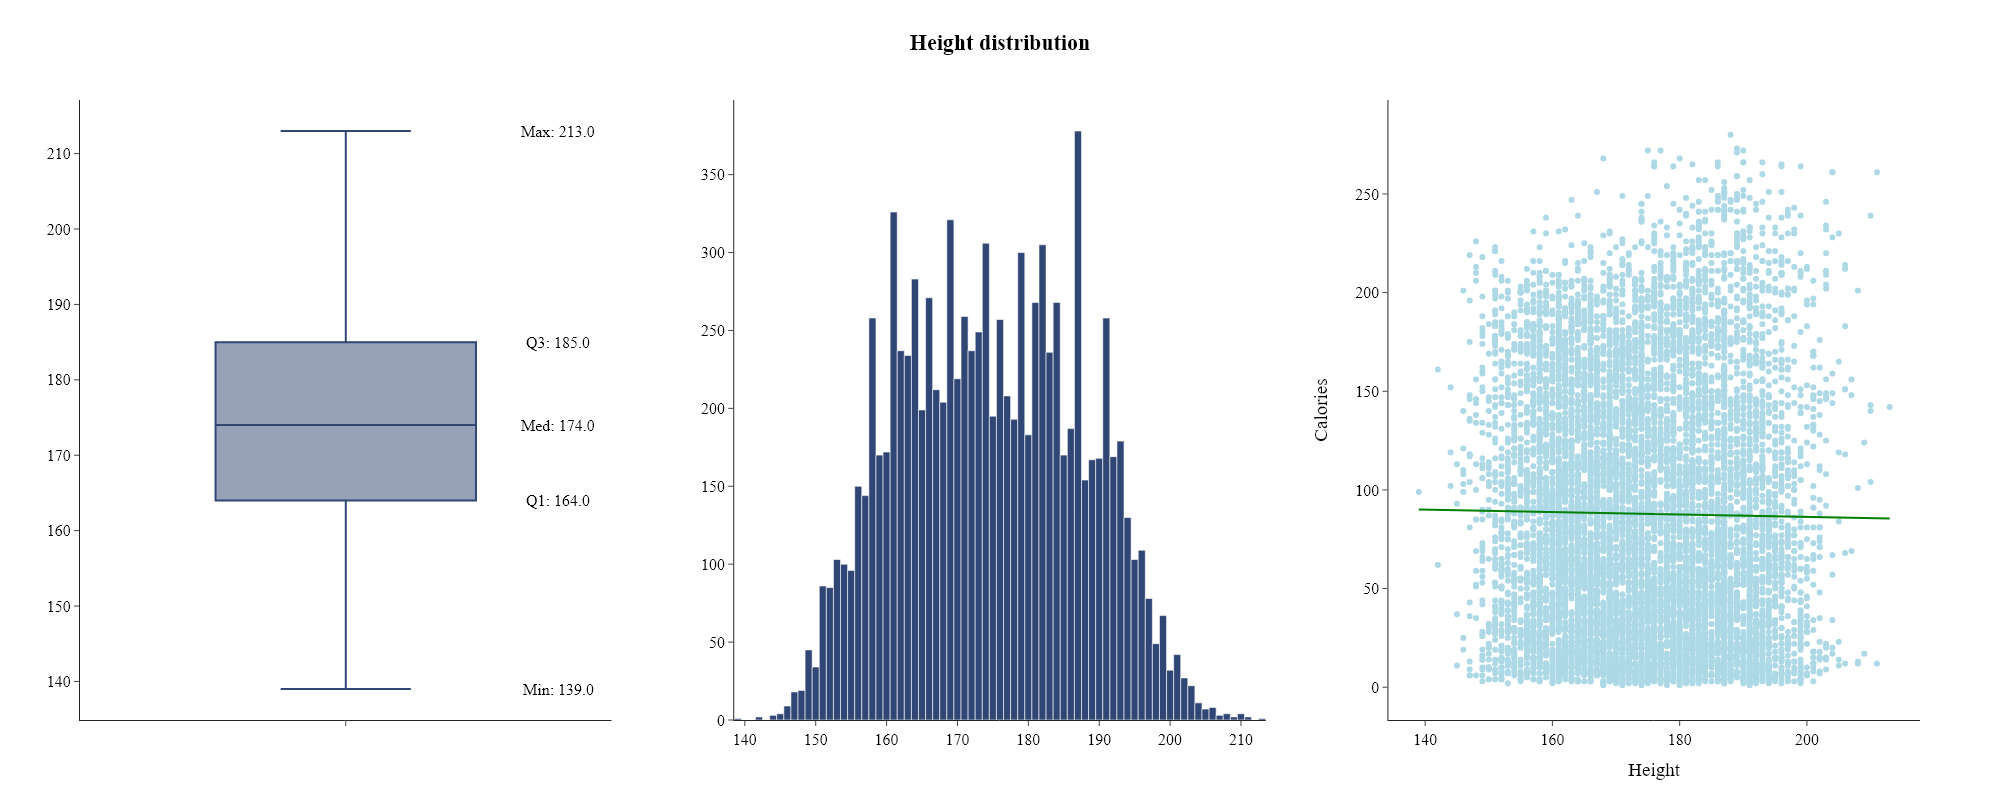

In [15]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Height", target=target_feature, name="Height", annotations=True, bin_size=1)

**Notes:**
- It looks like the `Height` almost does not affect the calorie burn rate.

**Conclusion:**
- I will convert the `Height` column to `int` dtype as it does not have decimal values (converting to `int` dtype reduces memory usage).

In [16]:
train_data['Height'] = train_data['Height'].astype(int)
test_data['Height'] = test_data['Height'].astype(int)

## `Weight`

`Weight` is a continuous variable representing the weight of person in kg.

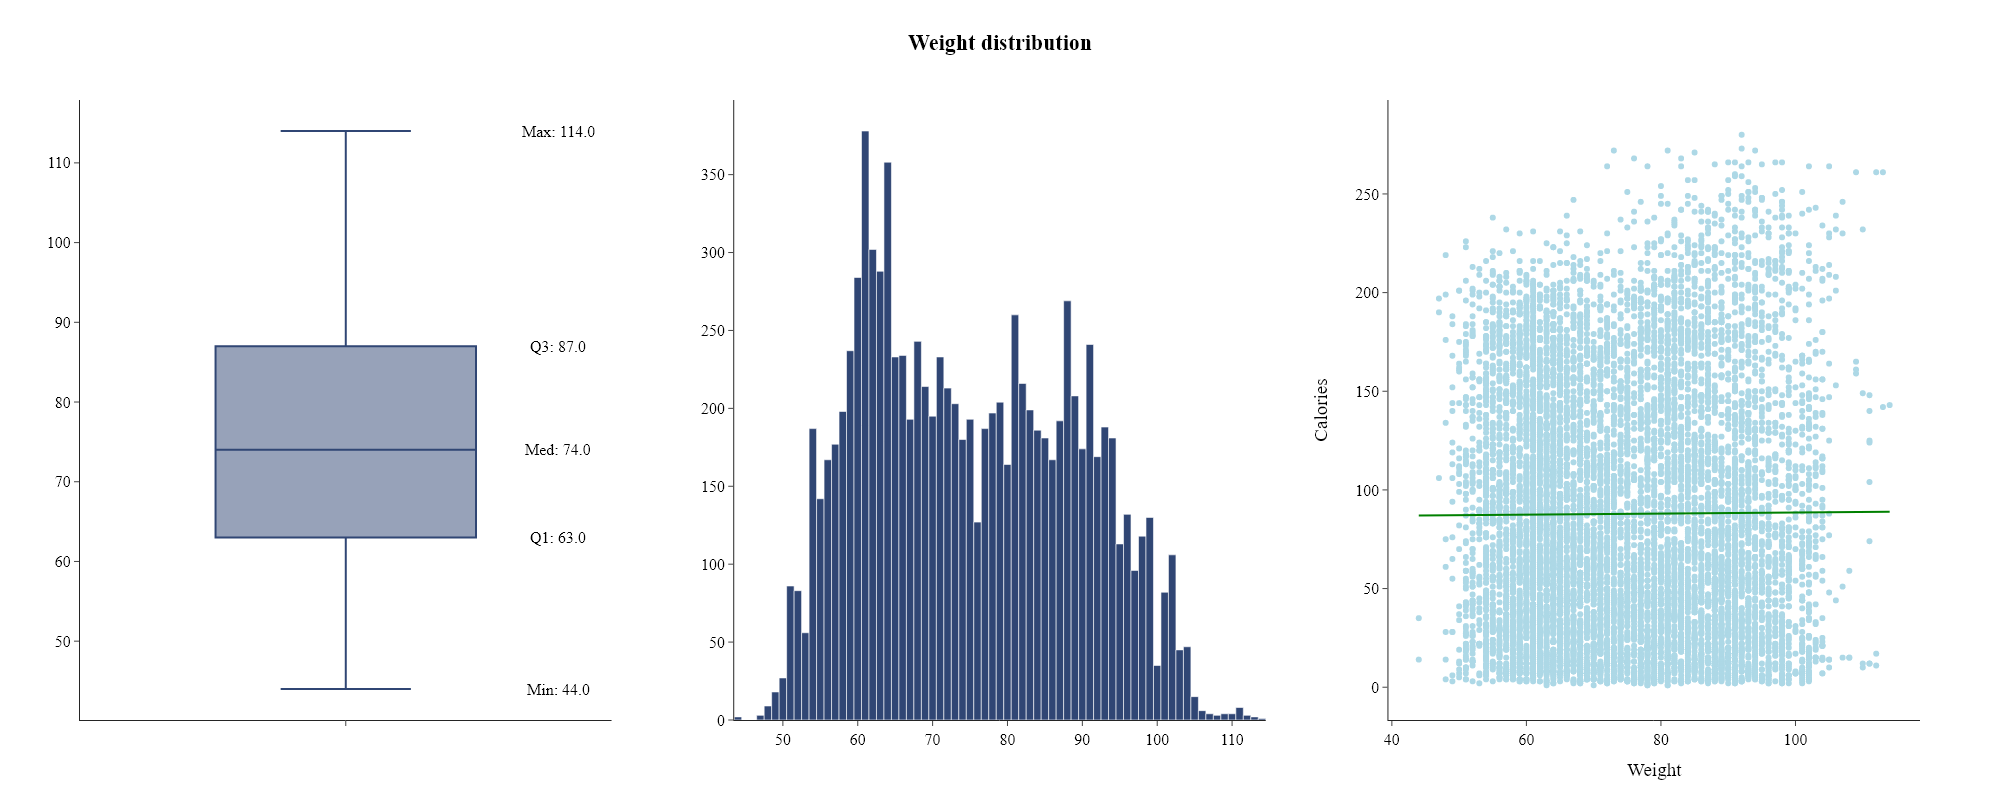

In [17]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Weight", target=target_feature, name="Weight", annotations=True, bin_size=1)

**Notes:**
- Similar to `Height`, `Weight` also does not seem to affect the calorie burn rate.

**Conclusion:**
- I will convert the `Weight` column to `int` dtype as it does not have decimal values (converting to `int` dtype reduces memory usage).
- I will create a new featrues:
    - `BMI` (Body Mass Index) using the formula: `Weight / (Height/100)^2`. This might be a good indicator of the calorie burn rate.
    - `BMR` (Basal Metabolic Rate) using the formula (https://www.garnethealth.org/news/basal-metabolic-rate-calculator):
        - For Men: BMR = 88.362 + (13.397 × weight in kg) + (4.799 × height in cm) - (5.677 × age)
        - For Women: BMR = 447.593 + (9.247 × weight in kg) + (3.098 × height in cm) - (4.330 × age)

In [18]:
train_data["Weight"] = train_data["Weight"].astype(int)
test_data["Weight"] = test_data["Weight"].astype(int)

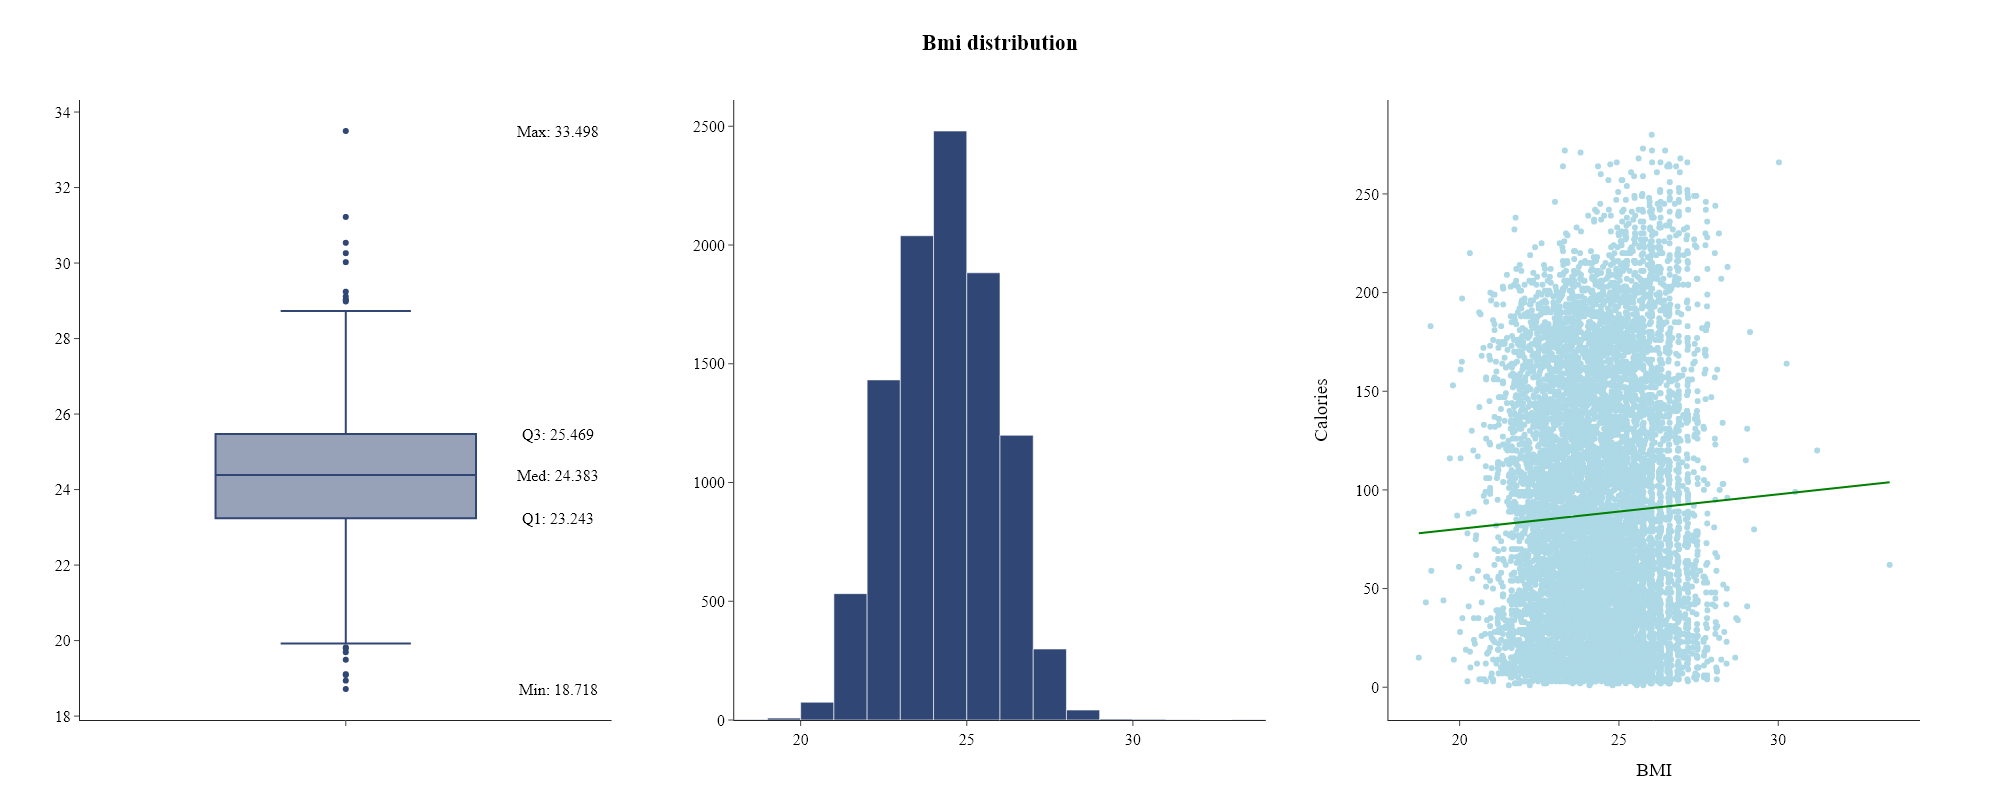

In [19]:
train_data["BMI"] = train_data["Weight"] / ((train_data["Height"] / 100) ** 2)
test_data["BMI"] = test_data["Weight"] / ((test_data["Height"] / 100) ** 2)
plots.histogram_boxplot_linear_regression(data=train_data, feature="BMI", target=target_feature, name="BMI", annotations=True, bin_size=1)

**Notes:**
- With the increase in BMI, the calorie burn rate also increases.

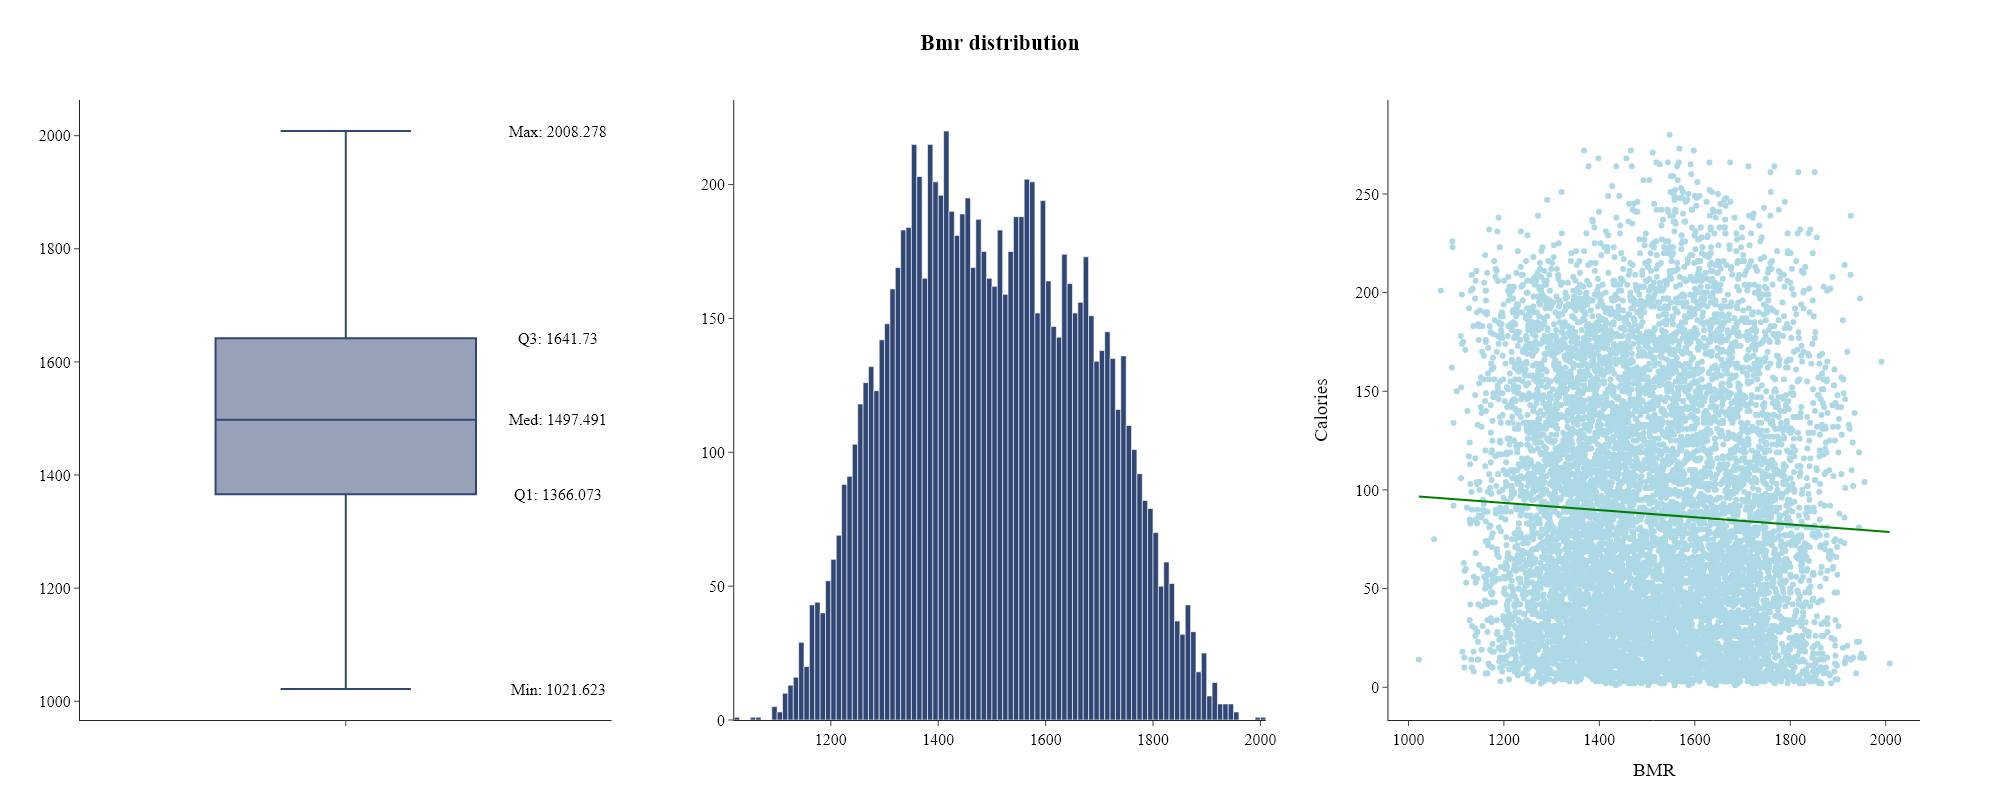

In [20]:
train_data['BMR'] = np.where(train_data['Sex'] == 'Male', 88.362 + (13.397 * train_data['Weight']) + (4.799 * train_data['Height']) - (5.677 * train_data['Age']), 447.593 + (9.247 * train_data['Weight']) + (3.098 * train_data['Height']) - (4.330 * train_data['Age']))
test_data['BMR'] = np.where(test_data['Sex'] == 'Male', 88.362 + (13.397 * test_data['Weight']) + (4.799 * test_data['Height']) - (5.677 * test_data['Age']), 447.593 + (9.247 * test_data['Weight']) + (3.098 * test_data['Height']) - (4.330 * test_data['Age']))
plots.histogram_boxplot_linear_regression(data=train_data, feature="BMR", target=target_feature, name="BMR", annotations=True, bin_size=10)

**Notes:**
- It looks like the `BMR` has less outliers than `BMI`.

## `Duration`

`Duration` is a continuous variable representing the duration of the training in minutes.

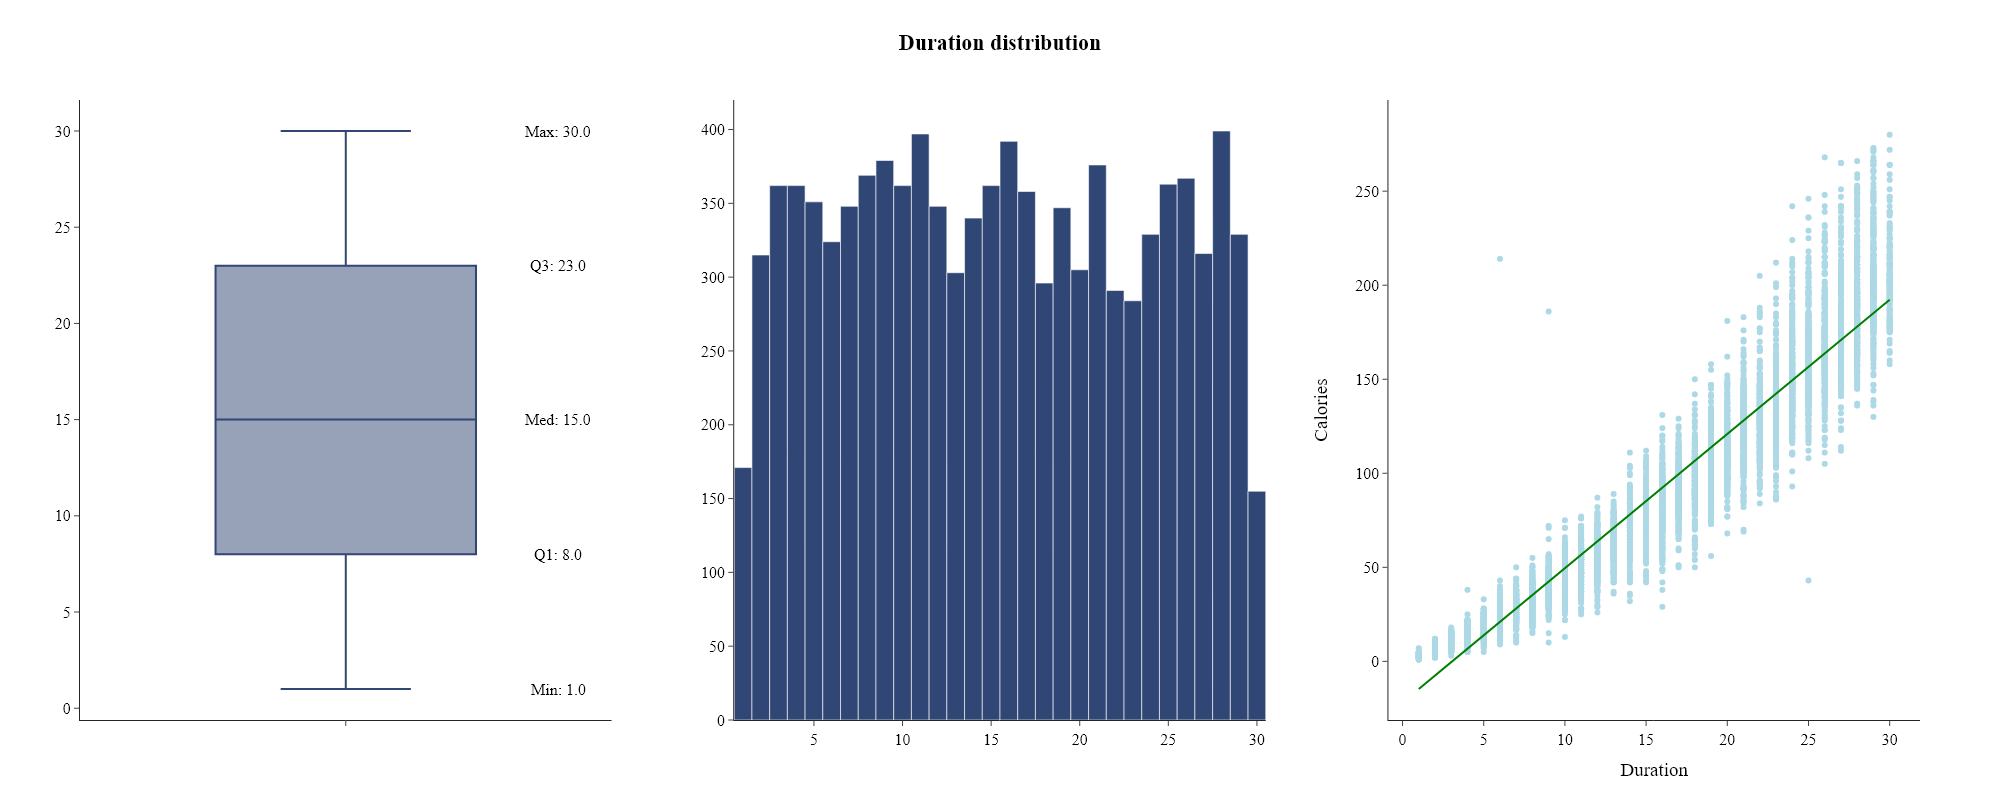

In [21]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Duration", target=target_feature, name="Duration", annotations=True, bin_size=1)

**Notes:**
- As expected, the calorie burn rate increases with the increase in duration.

**Conclusion:**
- I will convert the `Duration` column to `int` dtype as it does not have decimal values (converting to `int` dtype reduces memory usage).

In [22]:
train_data["Duration"] = train_data["Duration"].astype(int)
test_data["Duration"] = test_data["Duration"].astype(int)

## `Heart_Rate`

`Heart_Rate` is a continuous variable representing the heart rate of the person in beats per minute (bpm).

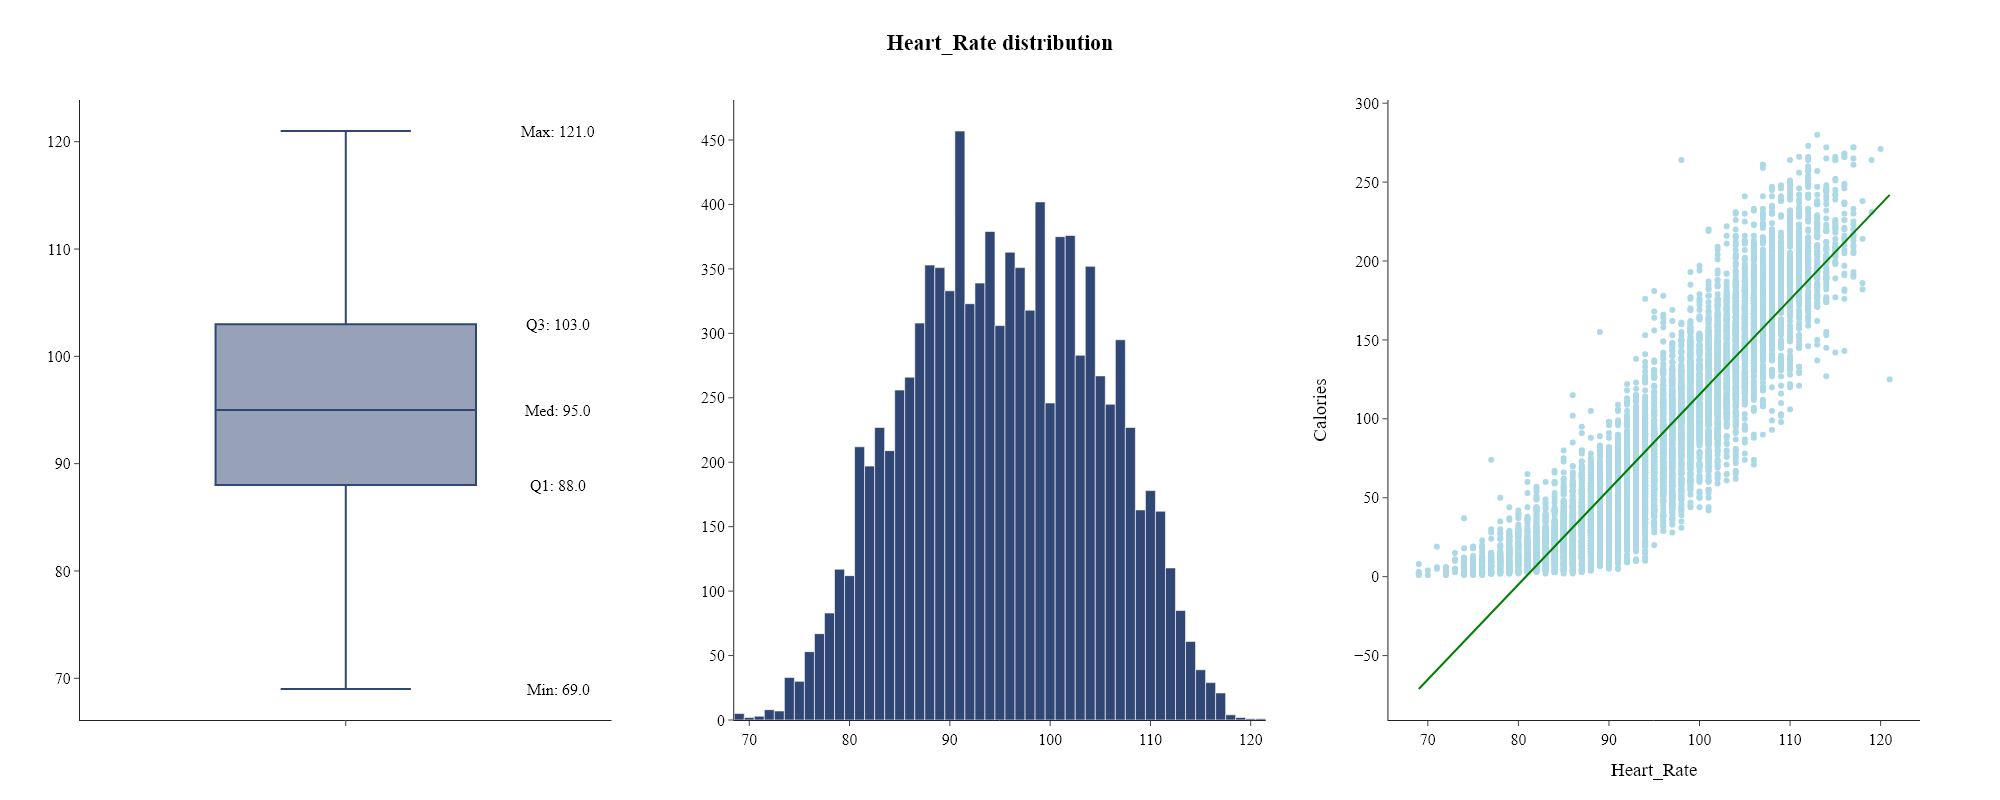

In [23]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Heart_Rate", target=target_feature, name="Heart_Rate", annotations=True, bin_size=1)

**Notes:**
- The `Heart_Rate` is almost normally distributed with a median of 95 bpm.
- The calorie burn rate is higher in the higher heart rate ranges.

**Conclusion:**
- I will convert the `Heart_Rate` column to `int` dtype as it does not have decimal values (converting to `int` dtype reduces memory usage).
- I will create new features:
    - `Intensity` based on `Heart_Rate` and `Duration`.
    - `Caloric_Burn_Rate` using the formula: `Caloric Burn Rate = Weight * Duration * Intensity`
    - `Maximum_Heart_Rate` using the formula: `Maximum Heart Rate = 220 - Age`.
    - `Heart_Zone` using the formula: `Heart Zone = (Heart Rate / Maximum Heart Rate) * 100`.
    - `MET` (Metabolic Equivalent of Task) using the formula (https://www.tandfonline.com/doi/pdf/10.1080/02640410470001730089?casa_token=xicOo9IeuHQAAAAA:C4nqH2d5zhUoig77q0SCb-N40uOfbIrxMg4zfgshHFWLehyw-3OQmy8FVfxoa4tQfdL1u_p-q_O0Kg):<br>`MET = sex*(-55.0969+0.6309*Heart Rate+0.1988*weight+0.2017*Age)+(1-sex)*(-20.4022+0.4472*Heart Rate+0.1263*weight+0.074*Age)`
    <br>Where `sex`=1 for male and `sex`=0 for female.

In [24]:
train_data["Heart_Rate"] = train_data["Heart_Rate"].astype(int)
test_data["Heart_Rate"] = test_data["Heart_Rate"].astype(int)

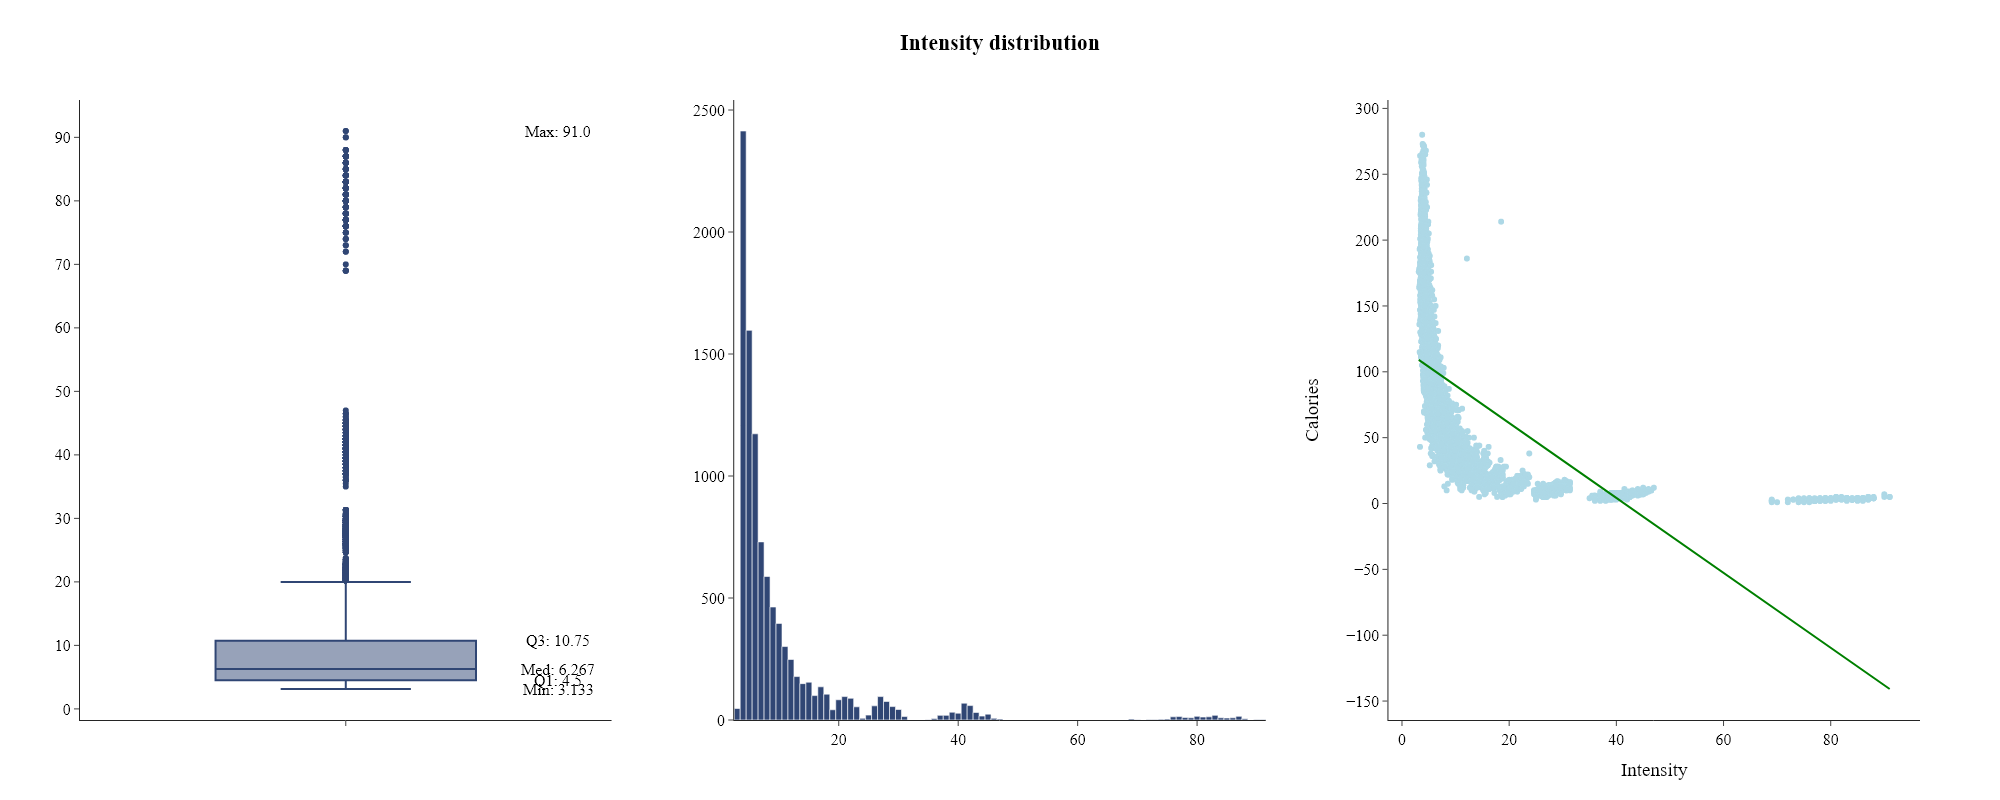

In [25]:
train_data["Intensity"] = train_data["Heart_Rate"] / train_data["Duration"]
test_data["Intensity"] = test_data["Heart_Rate"] / test_data["Duration"]
plots.histogram_boxplot_linear_regression(data=train_data, feature="Intensity", target=target_feature, name="Intensity", annotations=True, bin_size=1)

**Notes:**
- The distrubution of `Intensity` is right-skewed with a long tail.

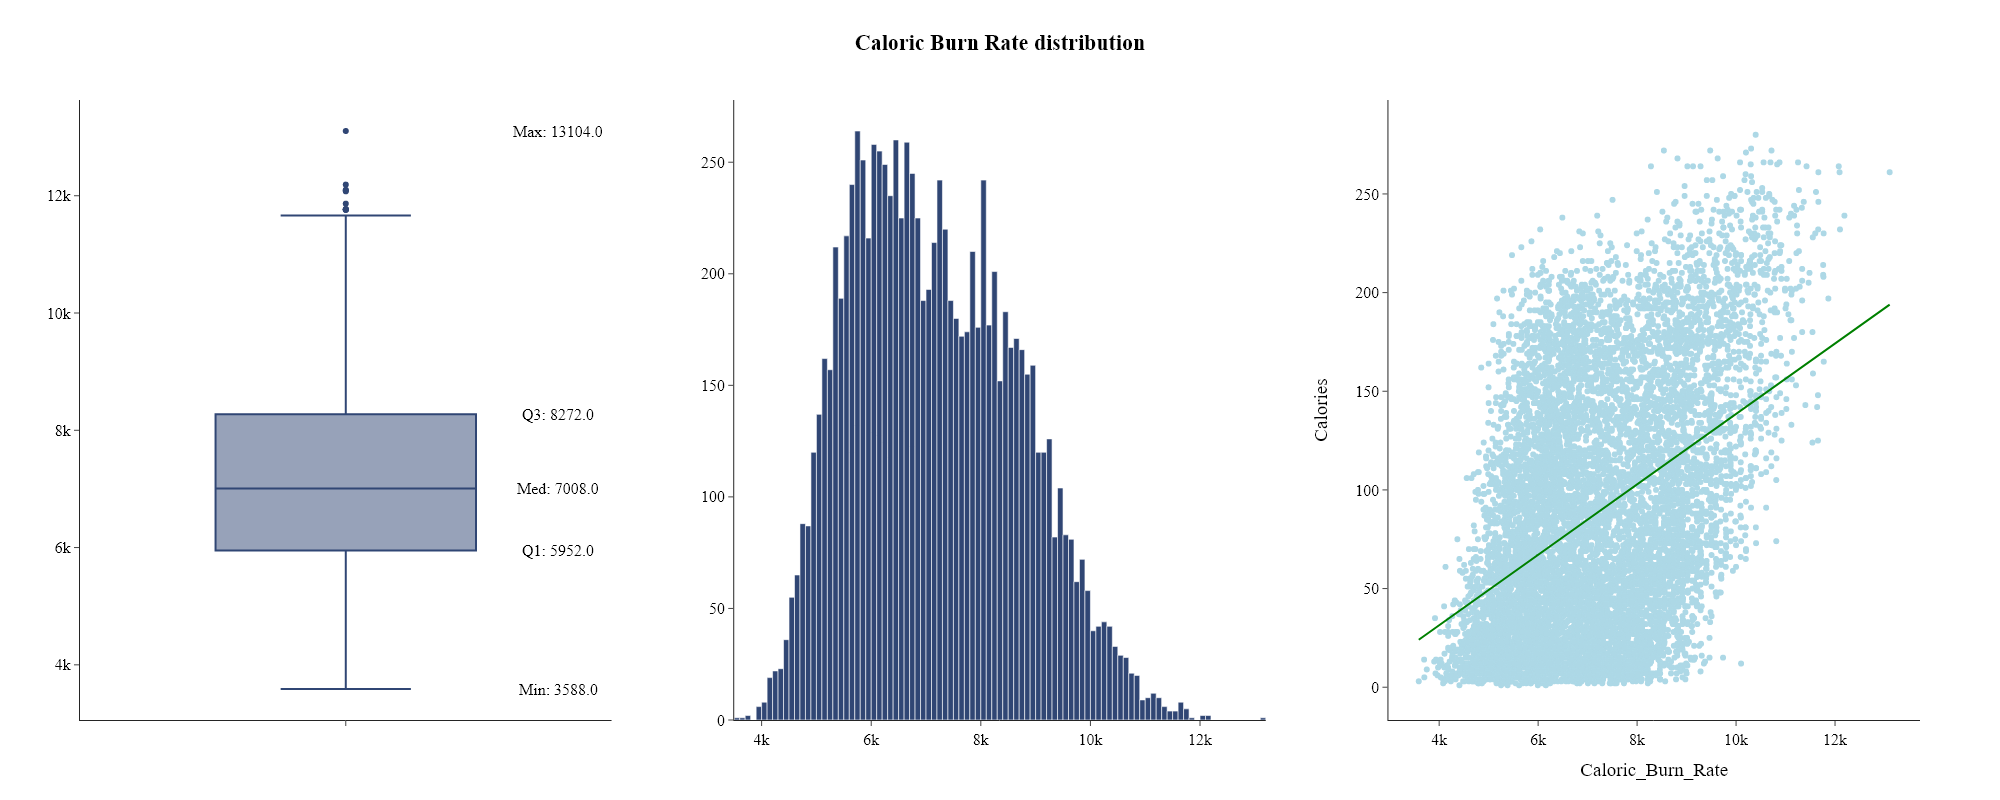

In [26]:
train_data["Caloric_Burn_Rate"] = train_data["Weight"]*train_data["Duration"]*train_data["Intensity"]
test_data["Caloric_Burn_Rate"] = test_data["Weight"]*test_data["Duration"]*test_data["Intensity"]
plots.histogram_boxplot_linear_regression(data=train_data, feature="Caloric_Burn_Rate", target=target_feature, name="Caloric Burn Rate", annotations=True, bin_size=100)

**Notes:**
- With the increase in `Caloric_Burn_Rate` it looks like `Calories` is also increasing.

**Conclusion:**
- I will convert the `Caloric_Burn_Rate` column to `int` dtype as it does not have decimal values (converting to `int` dtype reduces memory usage).

In [27]:
train_data["Caloric_Burn_Rate"] = train_data["Caloric_Burn_Rate"].astype(int)
test_data["Caloric_Burn_Rate"] = test_data["Caloric_Burn_Rate"].astype(int)

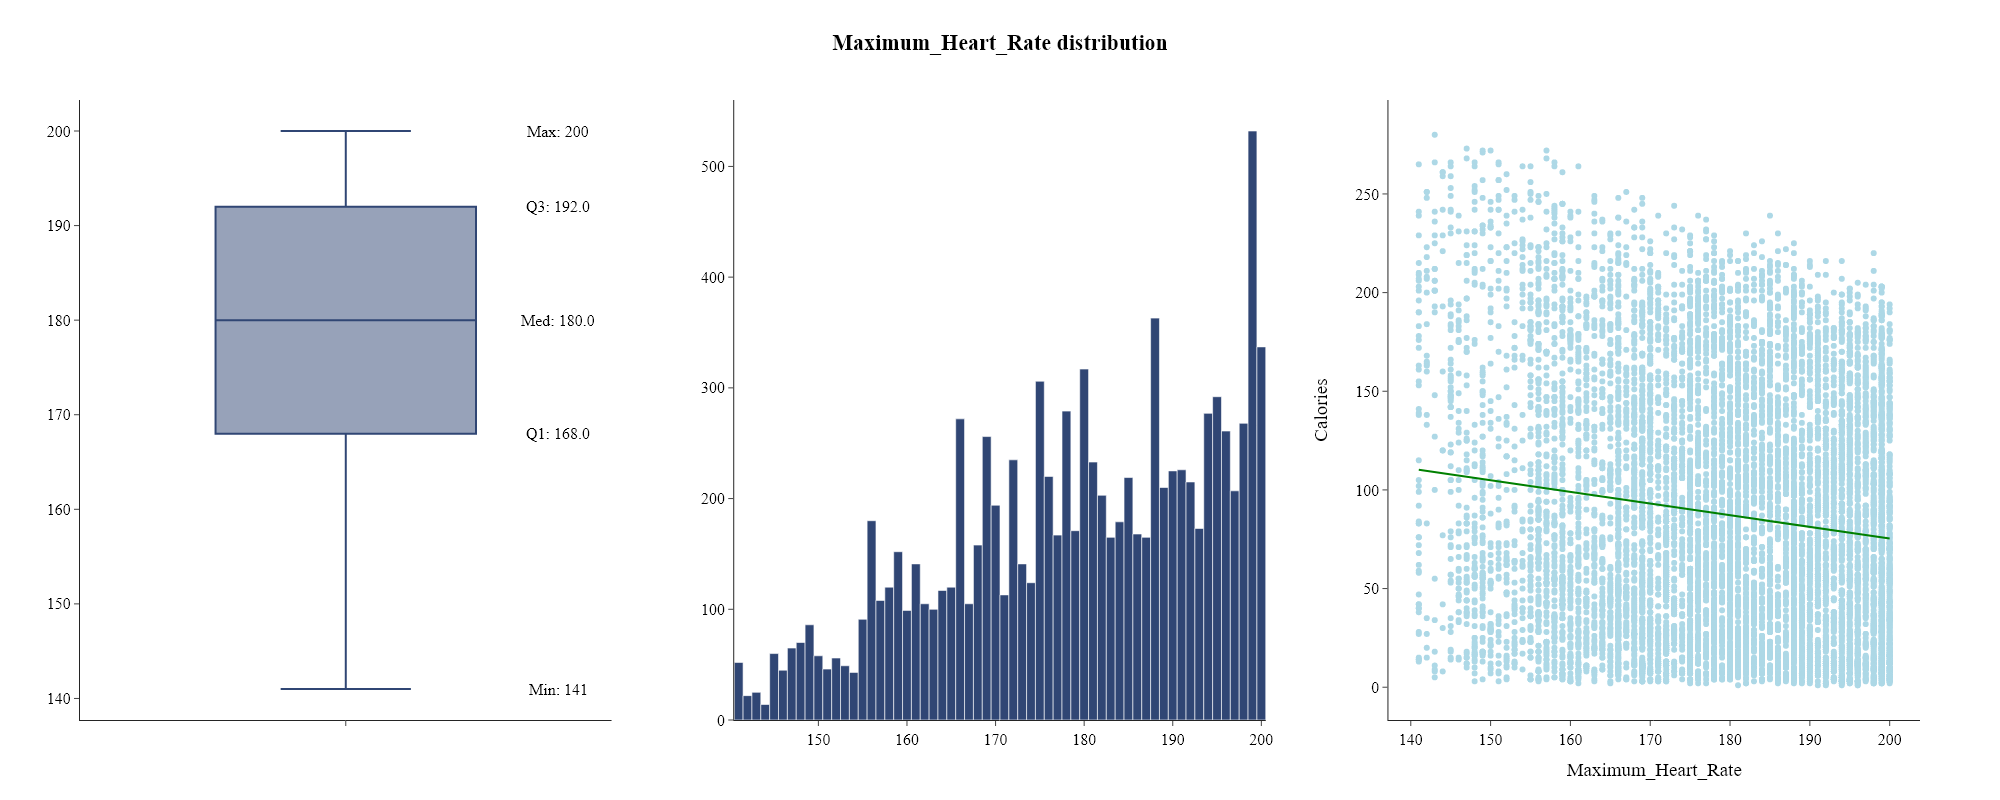

In [28]:
train_data["Maximum_Heart_Rate"] = 220 - train_data["Age"]
test_data["Maximum_Heart_Rate"] = 220 - test_data["Age"]
plots.histogram_boxplot_linear_regression(data=train_data, feature="Maximum_Heart_Rate", target=target_feature, name="Maximum_Heart_Rate", annotations=True, bin_size=1)

**Notes:**
- There is no strong relationship between `Maximum_Heart_Rate` and target variable.

**Conclusion:**
- I will convert the `Maximum_Heart_Rate` column to `int` dtype as it does not have decimal values (converting to `int` dtype reduces memory usage).

In [29]:
train_data["Maximum_Heart_Rate"] = train_data["Maximum_Heart_Rate"].astype(int)
test_data["Maximum_Heart_Rate"] = test_data["Maximum_Heart_Rate"].astype(int)

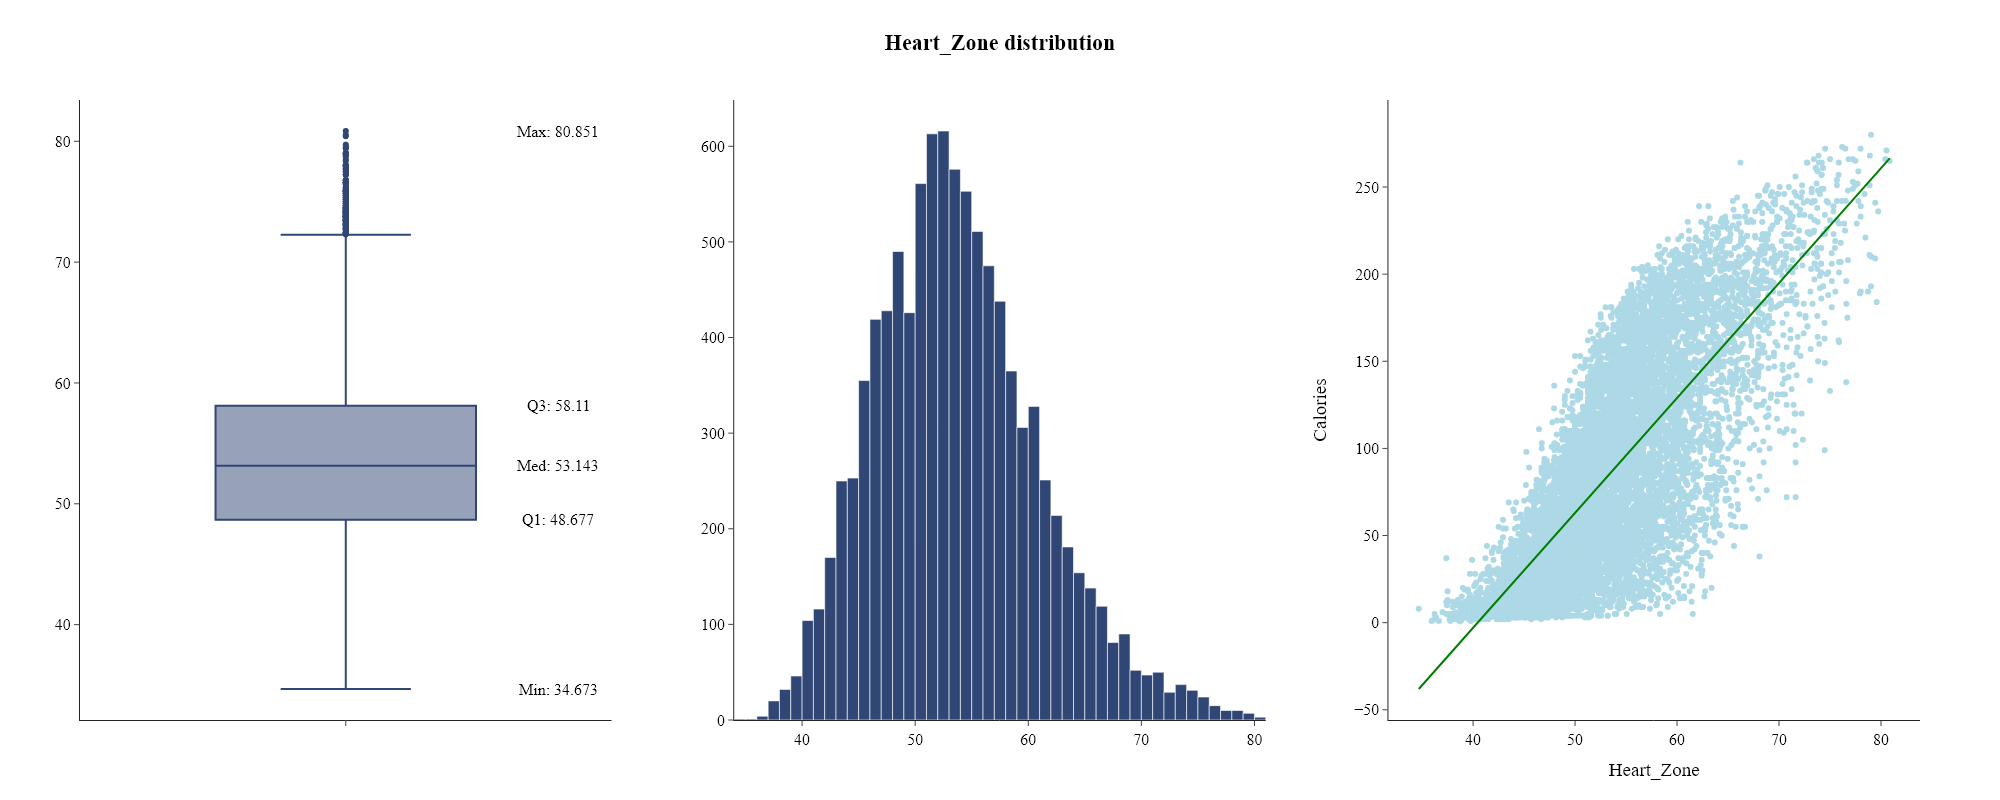

In [30]:
train_data["Heart_Zone"] = train_data["Heart_Rate"] / train_data["Maximum_Heart_Rate"] * 100
test_data["Heart_Zone"] = test_data["Heart_Rate"] / test_data["Maximum_Heart_Rate"] * 100
plots.histogram_boxplot_linear_regression(data=train_data, feature="Heart_Zone", target=target_feature, name="Heart_Zone", annotations=True, bin_size=1)

**Notes:**
- Similar to `Caloric_Burn_Rate`, the `Heart_Zone` it is positively correlated with the `Calories` burned.

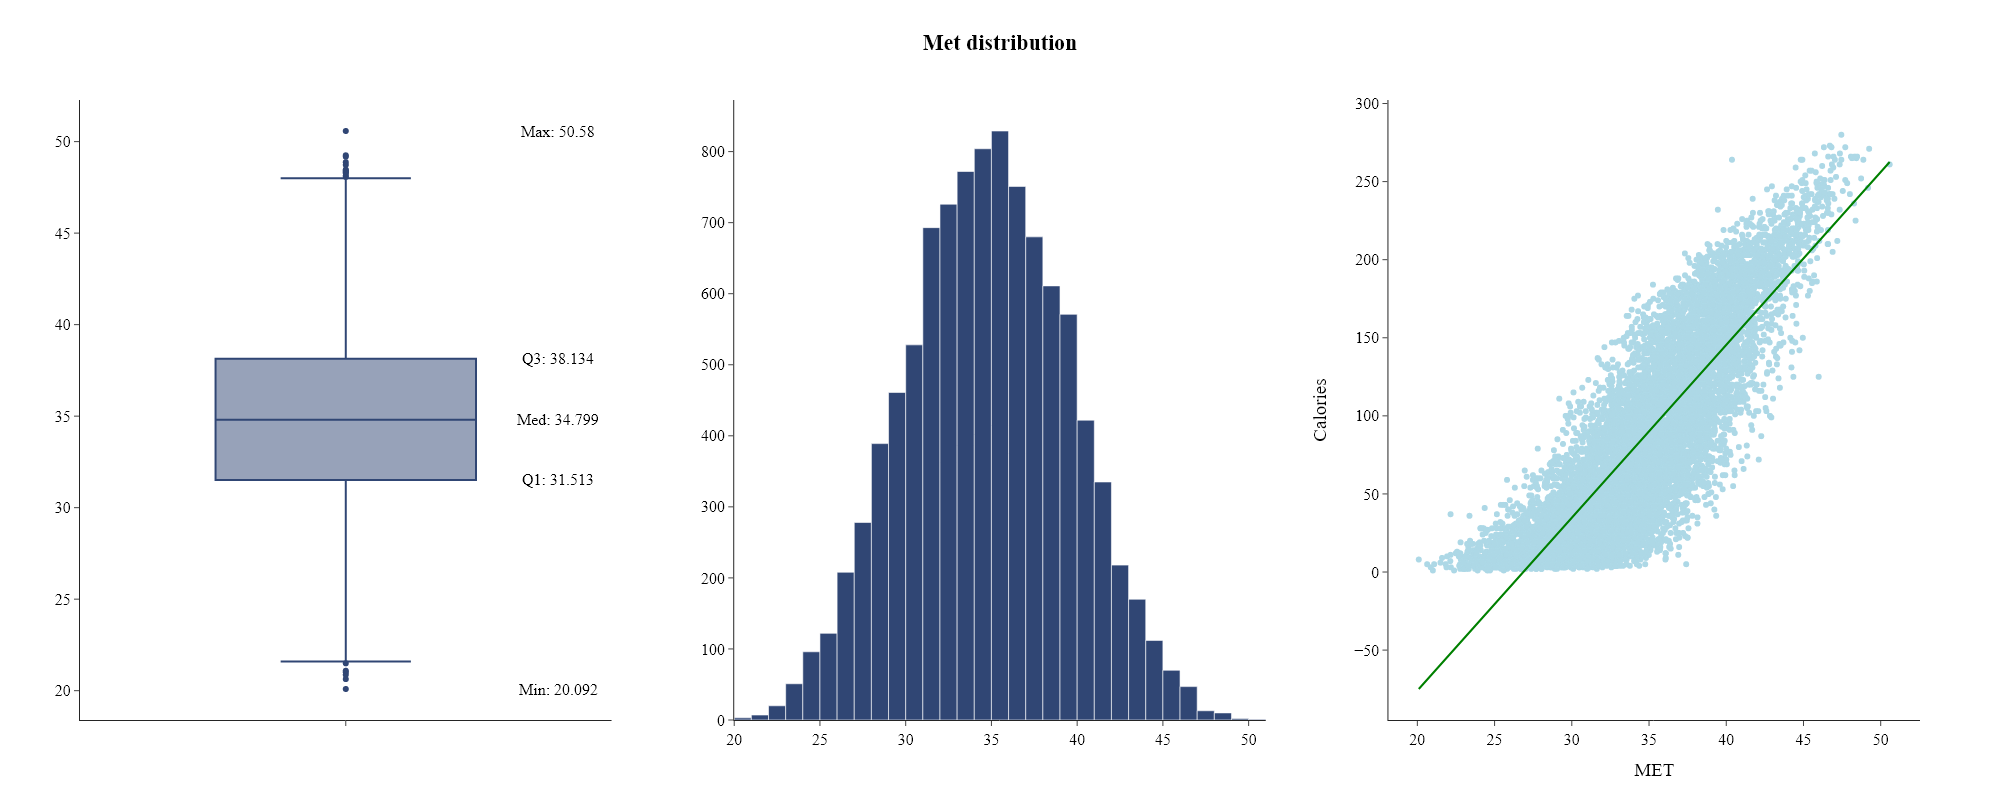

In [31]:
train_data["MET"] = np.where(train_data['Sex'] == 'Male', -55.0969 + (0.6309 * train_data['Heart_Rate']) + (0.1988 * train_data['Weight']) + (0.2017 * train_data['Age']), -20.4022 + (0.4472 * train_data['Heart_Rate']) + (0.1263 * train_data['Weight']) + (0.074 * train_data['Age']))
test_data["MET"] = np.where(test_data['Sex'] == 'Male', -55.0969 + (0.6309 * test_data['Heart_Rate']) + (0.1988 * test_data['Weight']) + (0.2017 * test_data['Age']), -20.4022 + (0.4472 * test_data['Heart_Rate']) + (0.1263 * test_data['Weight']) + (0.074 * test_data['Age']))
plots.histogram_boxplot_linear_regression(data=train_data, feature="MET", target=target_feature, name="MET", annotations=True, bin_size=1)

**Notes:**
- As expected, the `MET` is positively correlated with the `Calories` burned.

## `Body_Temp`

`Body_Temp` is a continuous variable representing the body temperature of the person in degrees Celsius.

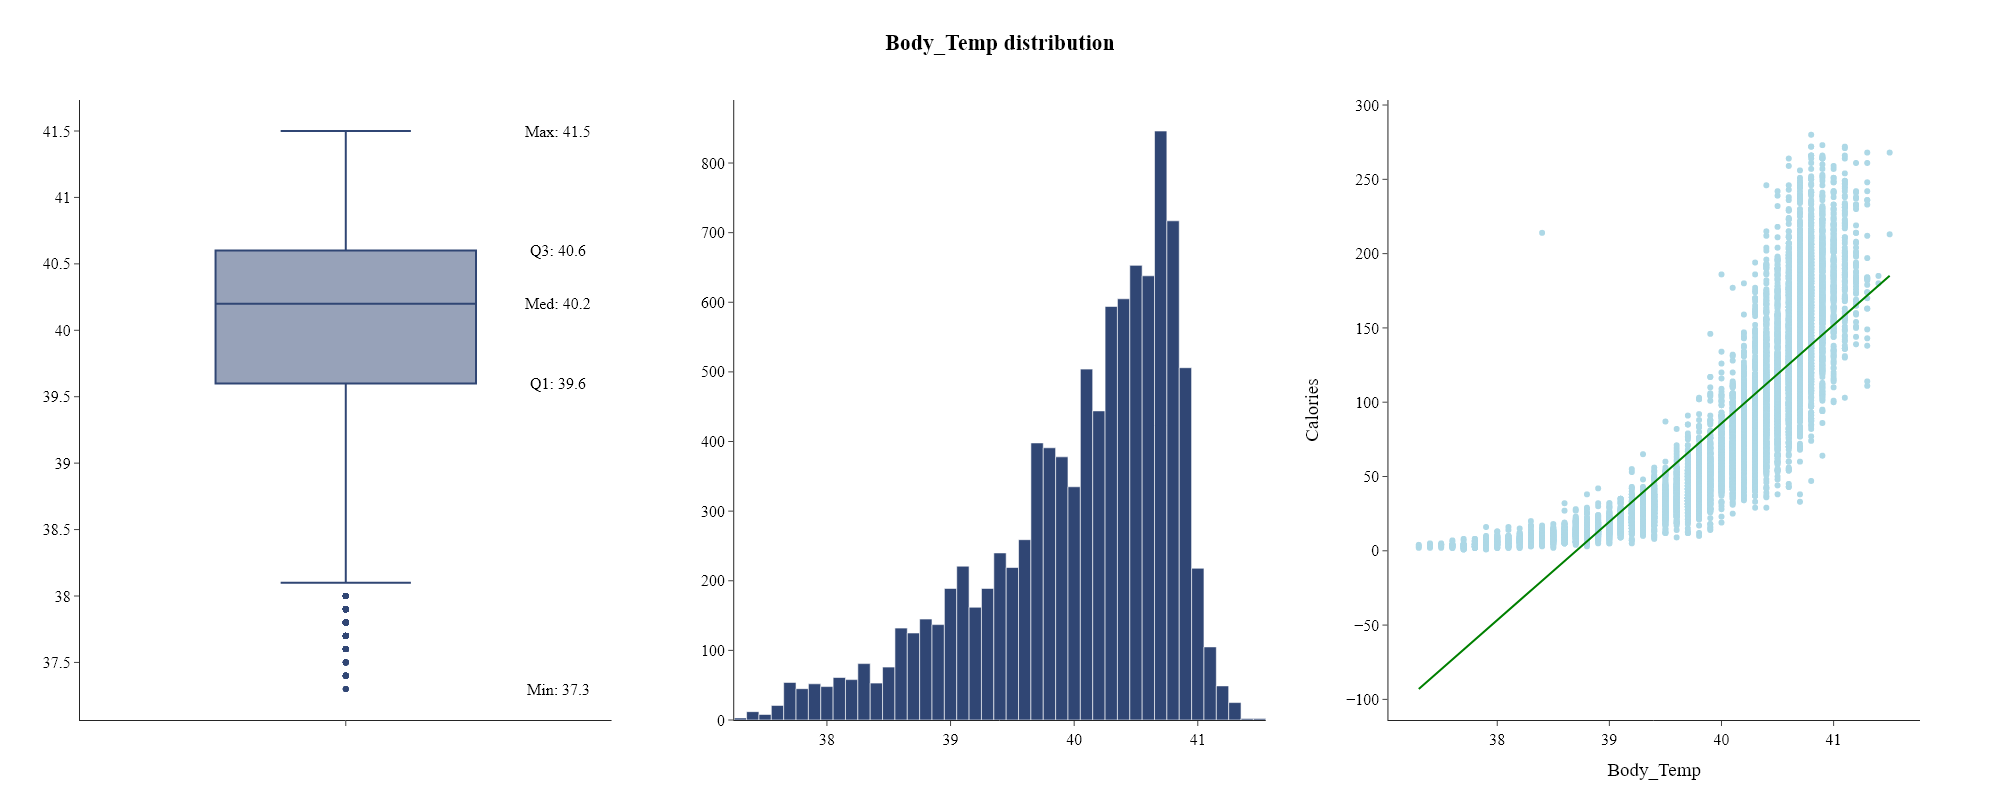

In [32]:
plots.histogram_boxplot_linear_regression(data=train_data, feature="Body_Temp", target=target_feature, name="Body_Temp", annotations=True, bin_size=0.1)

**Notes:**
- There is non linear relationship between `Body_Temp` and target variable.

## `Calories`

`Calories` is the target variable representing the calories burned during the training session.

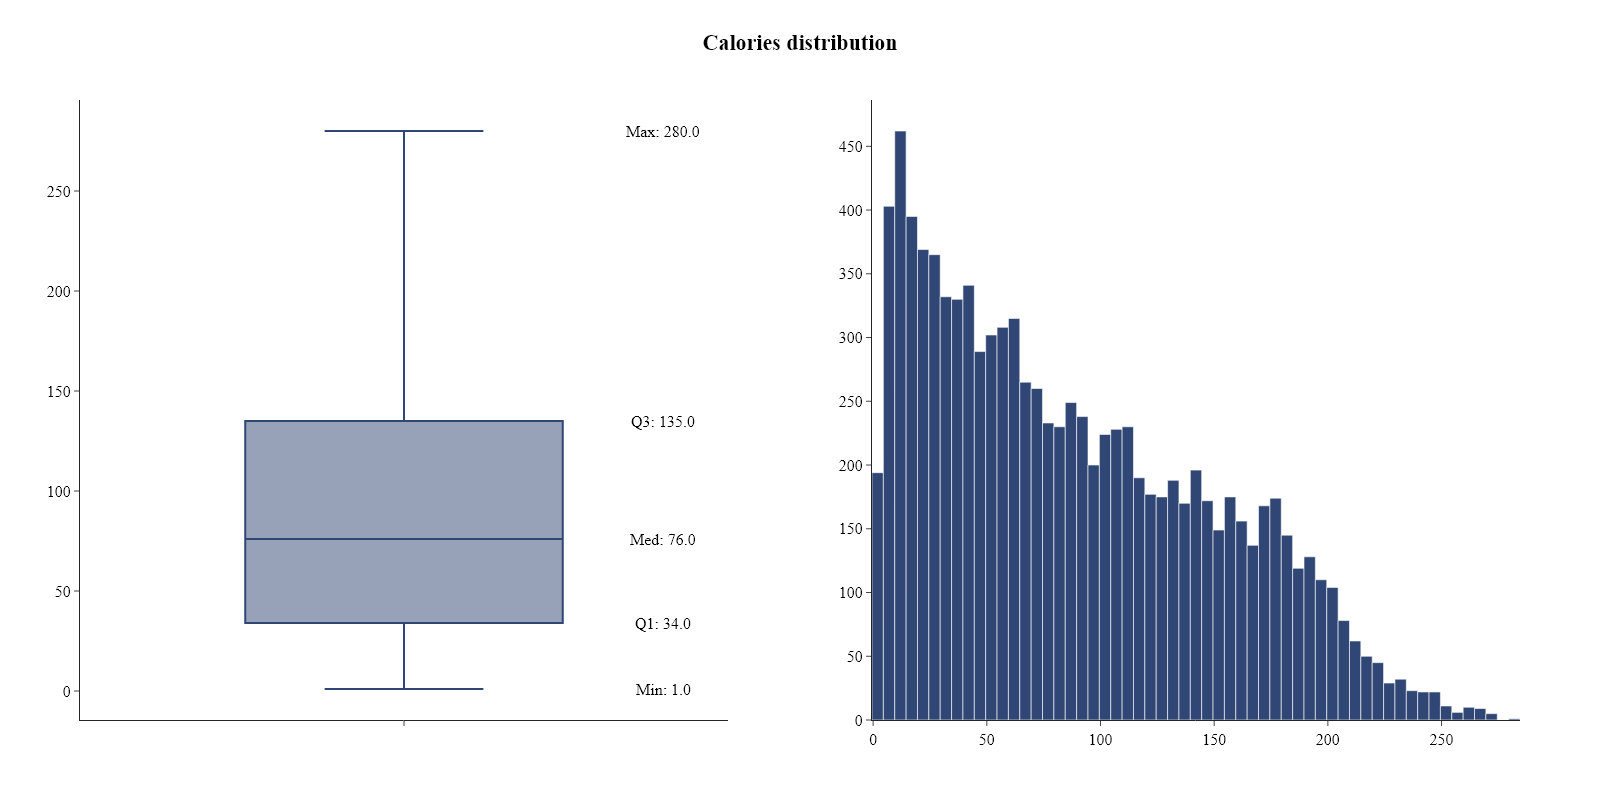

In [33]:
plots.histogram_and_box_plot(data=train_data[target_feature], name=target_feature, annotations=True, bin_size=5)

**Notes:**
- Distribution of `Calories` is right-skewed.
- Median of target variables is around 300 calories.

**Conclusion:**
- I will convert the column to `int` dtype as it does not have decimal values (converting to `int` dtype reduces memory usage).

In [34]:
train_data[target_feature] = train_data[target_feature].astype(int)

## Summary

In [35]:
categorical_features = train_data.select_dtypes(include=["category"]).columns.tolist()
numerical_features = train_data.select_dtypes(exclude=["category"]).columns.tolist()
independent_features = train_data.columns.difference([target_feature]).tolist()
base_information(train_data)

,dtypes,Number of missing values,Percentage of missing values,Unique values,Count
Sex,category,0,0.000000,2,10000
Age,int64,0,0.000000,60,10000
Height,int32,0,0.000000,71,10000
Weight,int32,0,0.000000,69,10000
Duration,int32,0,0.000000,30,10000
Heart_Rate,int32,0,0.000000,53,10000
Body_Temp,float64,0,0.000000,43,10000
Calories,int32,0,0.000000,267,10000
Age_Group,category,0,0.000000,6,10000
BMI,float64,0,0.000000,1062,10000


# Global data analysis

# Numerical data analysis

## Correlation matrix

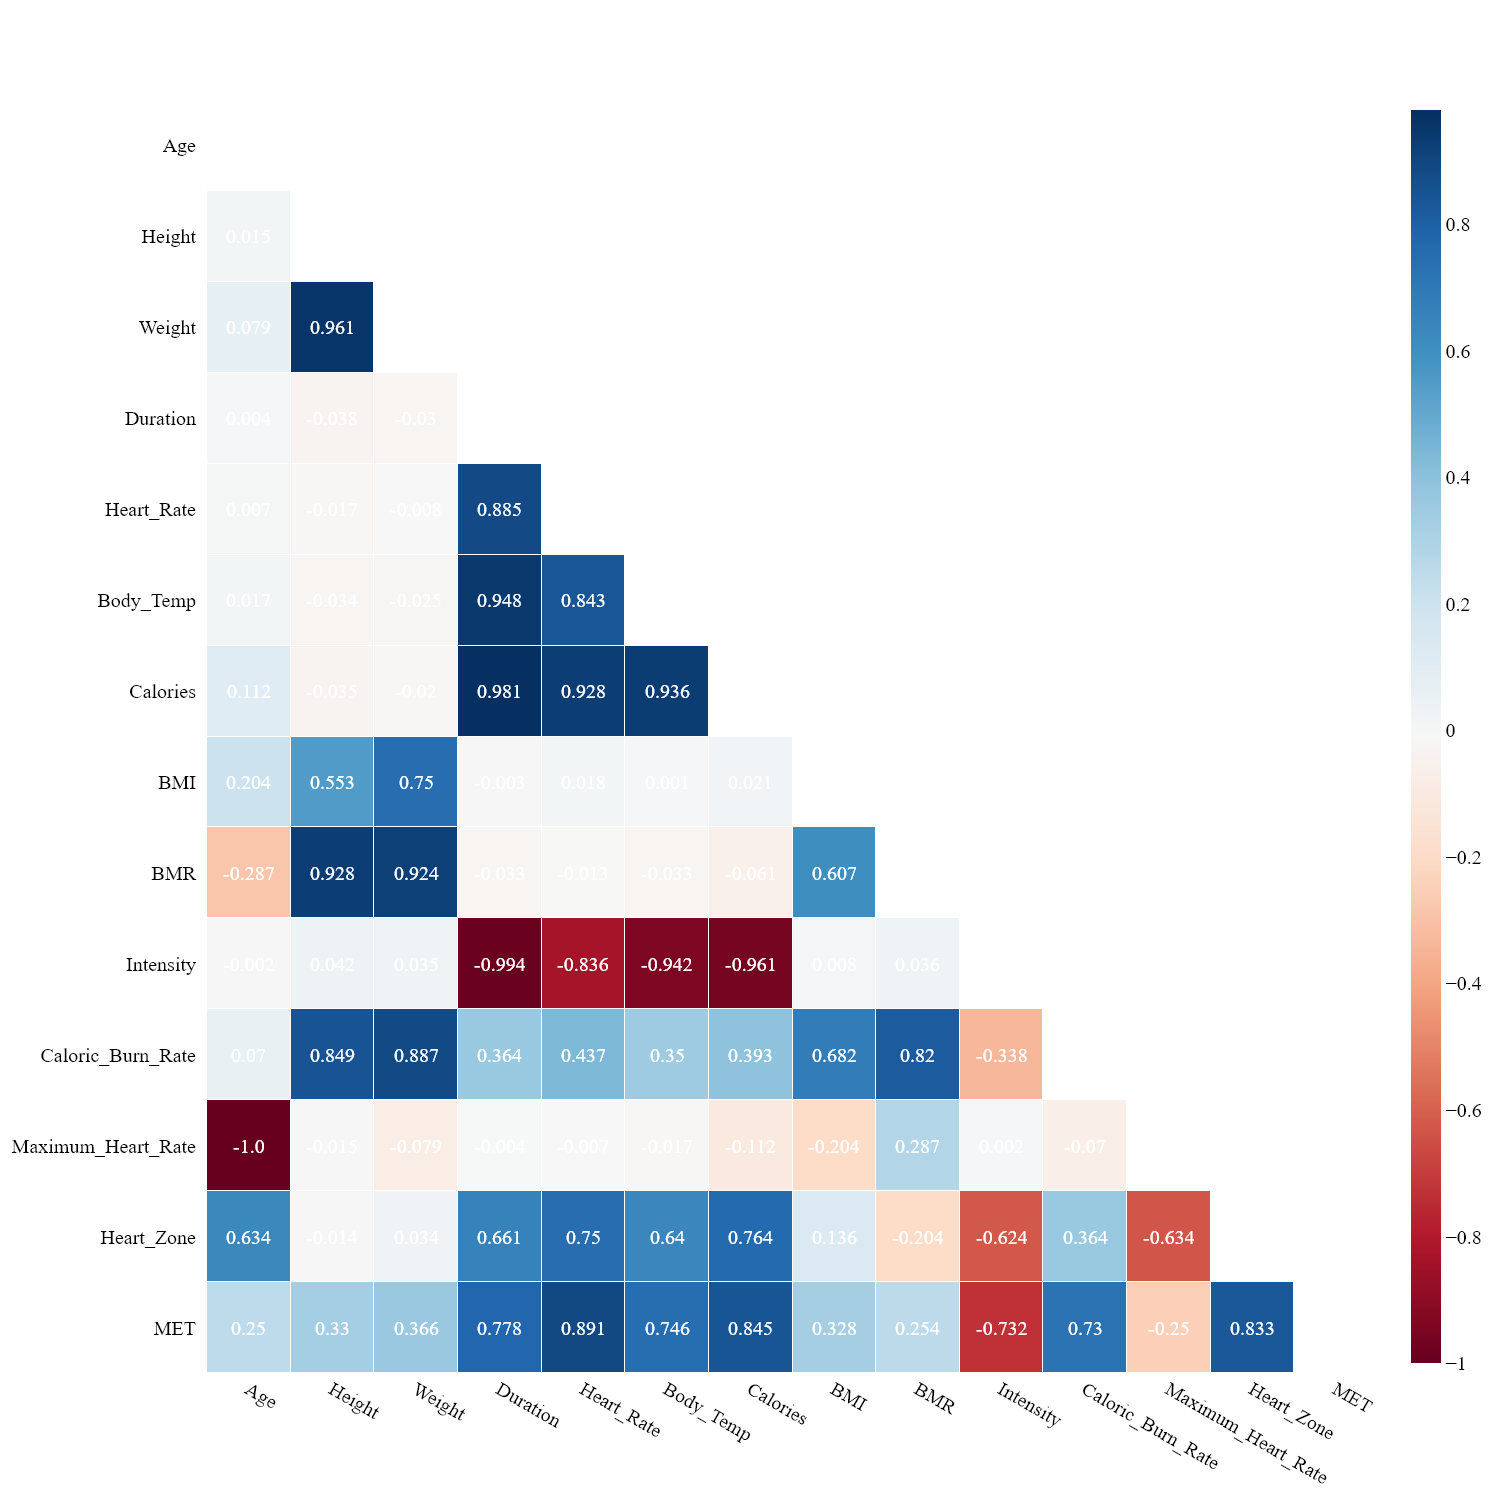

In [36]:
plots.correlation_plot(train_data[numerical_features], features_names=numerical_features, method="spearman")

**Notes:**
- There are plenty of features highly correlated with target variable. The highest positive correlation is with `Duration`. The highest negative correlation is with `Intensity`.

## VIF

To check whether multi-collinearity is present in the dataset, we will calculate the Variance Inflation Factor (VIF) for each continuous feature.

In [37]:
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_features
vif_data["VIF"] = [variance_inflation_factor(train_data[numerical_features].values, i) for i in range(len(numerical_features))] 
vif_data.sort_values("VIF", ascending=False, inplace=True)
vif_data.reset_index(drop=True, inplace=True)
vif_data

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar 

,feature,VIF
0,Age,inf
1,Height,inf
2,Weight,inf
3,Heart_Rate,inf
4,BMR,inf
5,Maximum_Heart_Rate,inf
6,MET,inf
7,Caloric_Burn_Rate,148.235169
8,Heart_Zone,127.075238
9,Duration,41.248373


# Categorical data analysis

## Chi square test

Chi square test is used to determine whether there is a significant association between two categorical variables.

Although our target variable is continous, we can create bins and treat it as categorical feature.

Below we will crate a temporary categorical feature based on target variable and then we will use chi square test to check whether there is a significant association between this temporary feature and other categorical features.

The temporary categorized target will have 5 unique values based on quantiles.

In [38]:
train_data_temp = train_data.copy()
train_data_temp[f"{target_feature}_bins"] = pd.qcut(train_data_temp[target_feature], q=5, labels=False)
train_data_temp[f"{target_feature}_bins"].value_counts()

Calories_bins
1    2022
0    2018
2    1998
4    1997
3    1965
Name: count, dtype: int64

In [39]:
class Chi_Square_Test:
    def check_X(
        self, X: pd.DataFrame | pd.Series | np.ndarray
    ) -> np.ndarray:
        """
        Check if X is pandas DataFrame, pandas Series or numpy array and convert it to numpy array.

        Args:
            X: (pd.DataFrame | pd.Series | np.ndarray): input data.

        Returns:
            X: (np.ndarray): converted input data.
        """
        if (
            not isinstance(X, pd.DataFrame)
            and not isinstance(X, pd.Series)
            and not isinstance(X, np.ndarray)
        ):
            raise TypeError(
                "Wrong type of X. It should be pandas DataFrame, pandas Series, numpy array."
            )
        X = np.array(X)
        if X.ndim == 1:
            X = X[None, :]
        return X

    def check_y(
        self, y: pd.DataFrame | pd.Series | np.ndarray
    ) -> np.ndarray:
        """
        Check if y is pandas DataFrame, pandas Series or numpy array and convert it to numpy array.

        Args:
            y: (pd.DataFrame | pd.Series | np.ndarray): target data.

        Returns:
            y: (np.ndarray): converted target data.
        """
        if (
            not isinstance(y, pd.DataFrame)
            and not isinstance(y, pd.Series)
            and not isinstance(y, np.ndarray)
        ):
            raise TypeError(
                "Wrong type of y. It should be pandas DataFrame, pandas Series, numpy array."
            )
        y = np.array(y)
        if y.ndim != 1:
            y = y.squeeze()
        return y

    def check_for_object_columns(self, X: np.ndarray) -> np.ndarray:
        """
        Check if X contains object columns and convert it to numeric data.

        Args:
            X: (np.ndarray): input data.

        Returns:
            X: (np.ndarray): converted input data.
        """
        X = pd.DataFrame(X)
        if X.select_dtypes(include=np.number).shape[1] != X.shape[1]:
            raise TypeError(
                "Your data contains object or string columns. Numeric data is obligated."
            )
        return np.array(X)

    def fit(
        self,
        X: pd.DataFrame | pd.Series | np.ndarray,
        y: pd.DataFrame | pd.Series | np.ndarray,
        alpha: float = 0.05,
    ):
        """
        Perform Chi Square test.

        Args:
            X: (pd.DataFrame | pd.Series | np.ndarray): input data.
            y: (pd.DataFrame | pd.Series | np.ndarray): target data.
            alpha: (float): significance level.
        """
        # X = self.check_X(X)
        # X = self.check_for_object_columns(X)
        # y = self.check_y(y)
        self.crosstab_ = self.crosstab_creation(X=X, y=y)
        self.check_assumptions(crosstab=self.crosstab_)
        self.test_statistic_ = self.calculate_chi_square_statistic(
            crosstab=self.crosstab_
        )
        self.df_ = self.calculate_degrees_of_freedom(crosstab=self.crosstab_)
        self.p_value_ = self.calculate_p_value(
            test_statistic=self.test_statistic_, df=self.df_
        )
        self.critical_value_ = self.calculate_critical_value(df=self.df_, alpha=alpha)
        self.keep_H0 = self.statistical_inference(p_value=self.p_value_, alpha=alpha)
        self.V_Cramera_ = self.calculate_V_Cramera(
            test_statistic=self.test_statistic_, crosstab=self.crosstab_
        )

    def crosstab_creation(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        """
        Create crosstab from input data.

        Args:
            X: (np.ndarray): input data.
            y: (np.ndarray): target data.

        Returns:
            crosstab: (np.ndarray): crosstab.
        """
        return np.array(pd.crosstab(X, y, margins=True))

    def check_assumptions(self, crosstab: np.ndarray) -> bool:
        """
        Check if assumptions for Chi Square test are met.

        Args:
            crosstab: (np.ndarray): crosstab.

        Raises:
            Warning: if assumptions are not met.
        """
        if not all(i <= 5 for i in crosstab.flatten()):
            self.assumption_ = False
            #warnings.warn("Assumptions for Chi Square test are not met.")
        else:
            self.assumption_ = True

    def calculate_chi_square_statistic(self, crosstab: np.ndarray) -> float:
        """
        Calculate Chi Square statistic.

        Args:
            crosstab: (np.ndarray): crosstab.

        Returns:
            chi_square: (float): Chi Square statistic.
        """
        chi_square = 0
        for row in range(0, crosstab.shape[0] - 1):
            for column in range(0, crosstab.shape[1] - 1):
                observed = crosstab[row][column]
                expected = crosstab[row][-1] * crosstab[-1][column] / crosstab[-1][-1]
                chi_square += (observed - expected) ** 2 / expected
        return chi_square

    def calculate_degrees_of_freedom(self, crosstab: np.ndarray) -> int:
        """
        Calculate degrees of freedom.

        Args:
            crosstab: (np.ndarray): crosstab.

        Returns:
            df: (int): degrees of freedom.
        """
        return (crosstab.shape[0] - 2) * (crosstab.shape[1] - 2)

    def calculate_p_value(self, test_statistic: float, df: int) -> float:
        """
        Calculate p value.

        Args:
            test_statistic: (float): test statistic.
            df: (int): degrees of freedom.

        Returns:
            p_value: (float): p value.
        """
        return 1 - chi2.cdf(x=test_statistic, df=df)

    def calculate_critical_value(self, df: int, alpha: float) -> float:
        """
        Calculate critical value.

        Args:
            df: (int): degrees of freedom.
            alpha: (float): significance level.

        Returns:
            critical_value: (float): critical value.
        """
        return chi2.isf(q=alpha, df=df)

    def statistical_inference(self, p_value: float, alpha: float) -> bool:
        """
        Perform statistical inference.

        Args:
            p_value: (float): p value.
            alpha: (float): significance level.

        Returns:
            bool: (bool): True if H0 is not rejected, False otherwise.
        """
        if p_value >= alpha:
            return True
        else:
            return False

    def calculate_V_Cramera(self, test_statistic: float, crosstab: np.ndarray) -> float:
        """
        Calculate V Cramer test statistic.

        Args:
            test_statistic: (float): test statistic.
            crosstab: (np.ndarray): crosstab.

        Returns:
            V_Cramer: (float): V Cramer test statistic.
        """
        return (
            test_statistic
            / (
                crosstab[-1][-1]
                * np.min([crosstab.shape[0] - 2, crosstab.shape[1] - 2])
            )
        ) ** 0.5

chi_square = Chi_Square_Test()

In [40]:
chi_square_results = pd.DataFrame(columns=["Feature", "p_value", "Test statistic", "Critical value", "H0 rejected", "V Cramera"])
for feature in categorical_features:
    chi_square.fit(X=train_data_temp[feature], y=train_data_temp[f"{target_feature}_bins"])
    chi_square_results = pd.concat([chi_square_results if not chi_square_results.empty else None, pd.DataFrame({"Feature": [feature], "p_value": [chi_square.p_value_], "Test statistic": [chi_square.test_statistic_], "Critical value": [chi_square.critical_value_], "H0 rejected": [not chi_square.keep_H0], "V Cramera": [chi_square.V_Cramera_]})])
chi_square_results.sort_values(by="Test statistic", ascending=False, inplace=True)
chi_square_results.reset_index(drop=True, inplace=True)
print(f"Percantage of features where H0 is not rejected (features are NOT associated with {target_feature}): {chi_square_results[chi_square_results['H0 rejected'] == False].shape[0]/len(chi_square_results)*100:.2f}%")
print(f"Percantage of features where H0 is rejected (features are associated with {target_feature}): {chi_square_results[chi_square_results['H0 rejected'] == True].shape[0]/len(chi_square_results)*100:.2f}%")
chi_square_results

Percantage of features where H0 is not rejected (features are NOT associated with Calories): 0.00%
Percantage of features where H0 is rejected (features are associated with Calories): 100.00%


,Feature,p_value,Test statistic,Critical value,H0 rejected,V Cramera
0,Age_Group,0.000000,220.293102,31.410433,True,0.074211
1,Sex,0.000005,30.054284,9.487729,True,0.054822


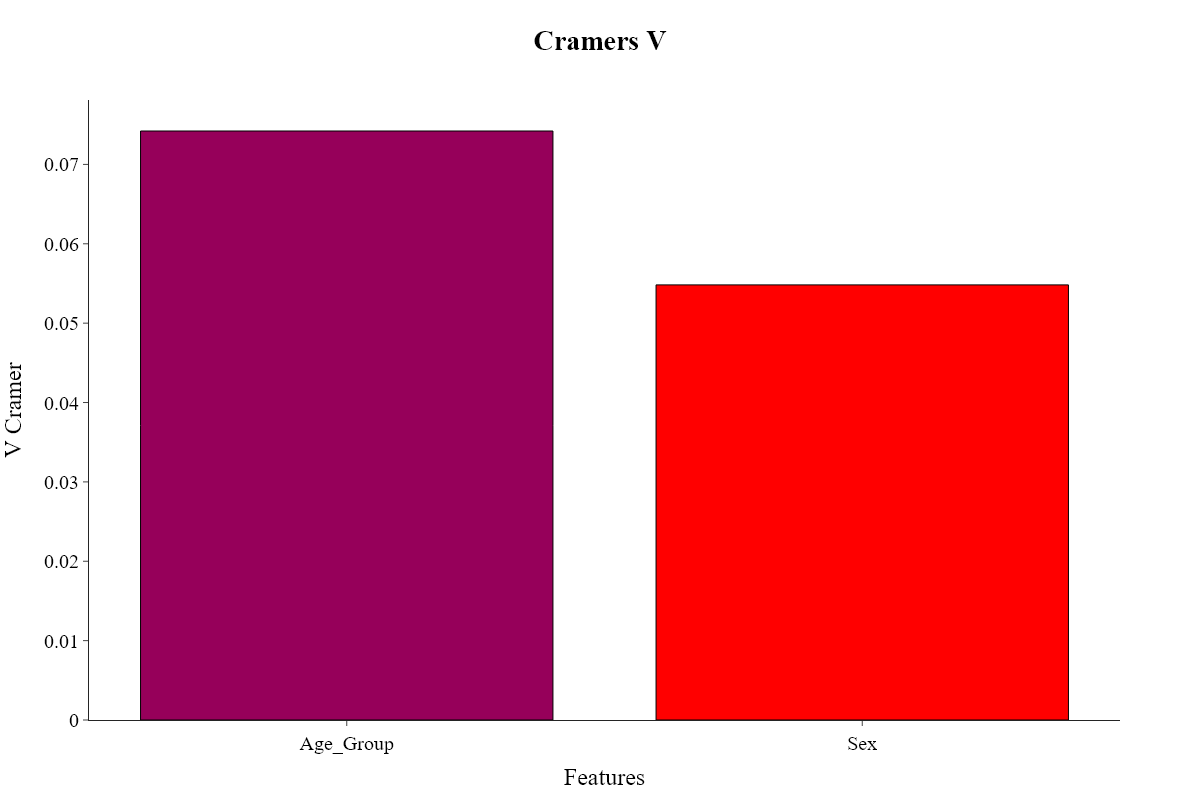

In [41]:
chi_square_results_sorted = chi_square_results.sort_values(by="V Cramera", ascending=False)
fig = go.Figure()
n_colors = len(chi_square_results_sorted)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors - 1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=chi_square_results_sorted["Feature"], y=chi_square_results_sorted["V Cramera"], marker=dict(color=colors, line=dict(color='black', width=1), line_color='black')))
fig.update_xaxes(title_text="Features")
fig.update_yaxes(title_text="V Cramer")
fig.update_layout(template="simple_white", width=1200, height=800, title="<b>Cramers V<b>", title_x=0.5, font=dict(family="Times New Roman", size=20, color="Black"))
fig.show("png")

**Notes:**
- The highest Cramer's V for binned target variable is with `Age_Group`.
- Cramer's V values are pretty low for all features which means that there is no strong association between the target variable and other categorical features.

**Conclusion:**
- We will drop binned target variable after this analysis.

In [42]:
train_data_temp.drop(f"{target_feature}_bins", axis=1, inplace=True)

# All features

## Mutual information

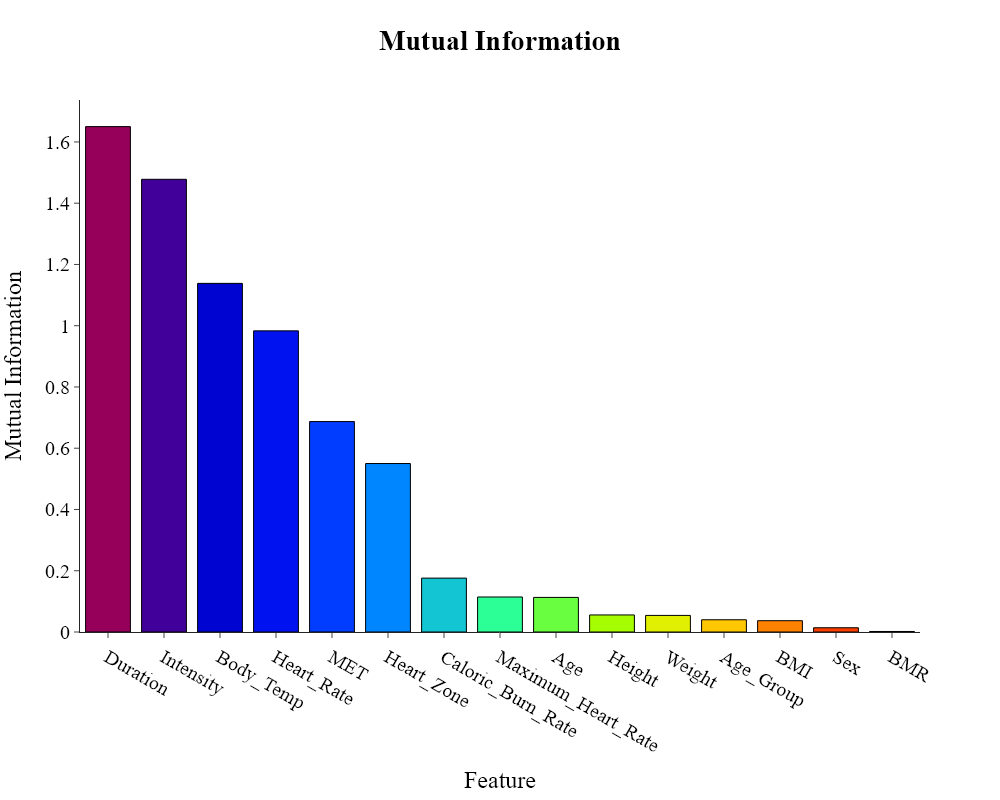

In [43]:
ordinal_encoder = OrdinalEncoder()
train_data_temp[categorical_features] = ordinal_encoder.fit_transform(train_data_temp[categorical_features])
mi_scores = {}
for feature in independent_features:
    if feature in categorical_features:
        mi_scores[feature] = mutual_info_regression(train_data_temp[[feature]], train_data_temp[target_feature], random_state=SEED, discrete_features=True)[0]
    else:
        mi_scores[feature] = mutual_info_regression(train_data_temp[[feature]], train_data_temp[target_feature], random_state=SEED)[0]
mi_scores = {k: v for k, v in sorted(mi_scores.items(), key=lambda item: item[1], reverse=True)}
fig = go.Figure()
n_colors = len(mi_scores)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(mi_scores.keys()), y=list(mi_scores.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black')))
fig.update_layout(template="simple_white", width=1000, height=800, title="<b>Mutual Information<b>", title_x=0.5, xaxis_title="Feature", yaxis_title=f"Mutual Information", font=dict(family="Times New Roman",size=20,color="Black"), showlegend=False)
fig.show("png")

**Notes:**
- There is a very strong relationship between `Duration` or `Intensity` and target variable.

## Outliers

Before applying Isolation Forest we will convert categorical features with the usage of pandas `get_dummies` function.

In [44]:
train_data_temp = train_data.copy()
train_data_temp = pd.get_dummies(train_data_temp, columns=categorical_features, drop_first=True)
train_data_temp.drop(target_feature, axis=1, inplace=True)

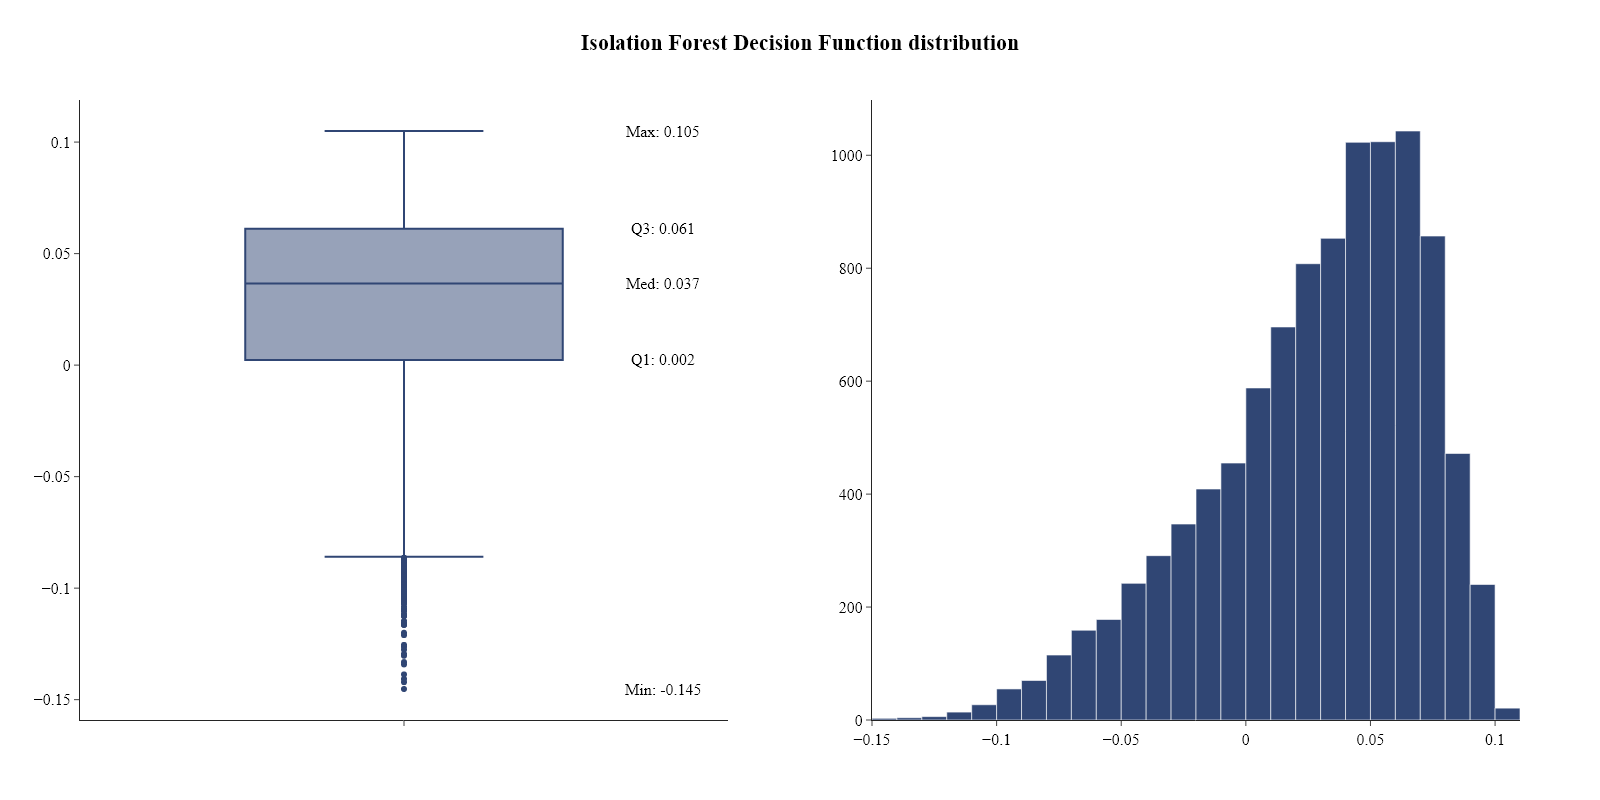

Number of outliers: 2375.
Proportion of outliers: 23.75%.


In [45]:
isolation_forest = IsolationForest(random_state=SEED, n_jobs=-1)
isolation_forest.fit(train_data_temp)
plots.histogram_and_box_plot(data=isolation_forest.decision_function(train_data_temp), name="Isolation Forest Decision Function", annotations=True, bin_size=0.01)
outliers = isolation_forest.predict(train_data_temp)
outliers = pd.Series(outliers)
print("Number of outliers: {}.".format(outliers[outliers == -1].shape[0]))
print("Proportion of outliers: {}%.".format(np.round(outliers[outliers == -1].shape[0] / train_data_temp.shape[0] * 100, 2)))

Before UMAP which is time consuming I will limit dataset to 10k observations.

In [46]:
train_data_temp = train_data_temp.sample(min(train_data_temp.shape[0], 10000))
outliers = isolation_forest.predict(train_data_temp)
outliers = pd.Series(outliers)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\umap\umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



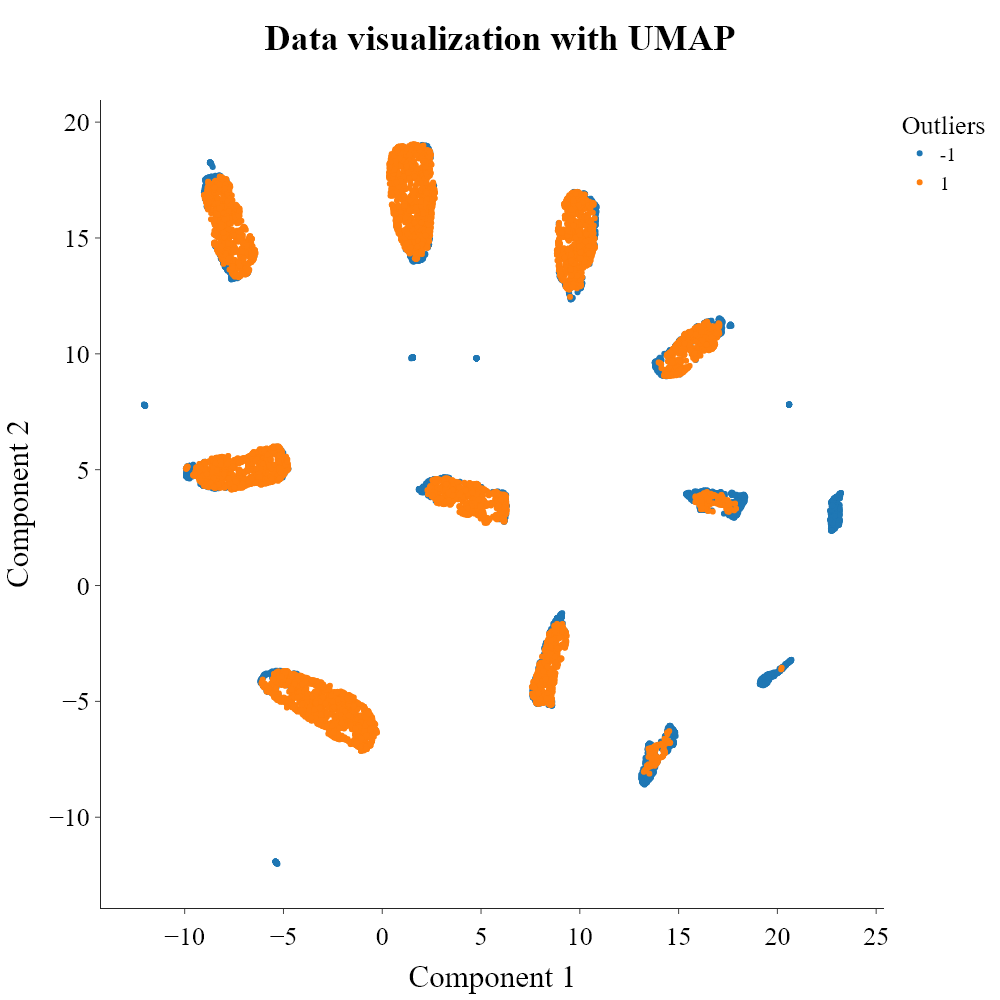

In [47]:
scaler = MinMaxScaler()
umap_model = UMAP(n_components=2, random_state=SEED, n_jobs=-1)
train_data_temp_scaled = scaler.fit_transform(train_data_temp)
X_umap = umap_model.fit_transform(train_data_temp_scaled)
plots.scatter_plot(data=X_umap, hue=outliers, hue_name="Outliers", name="Data visualization with UMAP")

**Notes:**
- We can clearly see some clusters in the data.
- It does not look like outliers were correctly detected by Isolation Forest (at least based on UMAP plot).

In [48]:
del train_data_temp, train_data_temp_scaled

# Modeling

## Base models

### LightGBM

In [49]:
model = LGBMRegressor(random_state=SEED, verbose=-1, n_jobs=-1, objective='regression', metric=compare_metric_name, linear_tree=True)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSLE: 0.0538 +- 0.0009
Validation RMSLE: 0.0664 +- 0.0038


### XGBoost

In [50]:
model = XGBRegressor(random_state=SEED, n_jobs=-1, objective='reg:squarederror', enable_categorical=True, tree_method='hist')
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSLE: 0.0426 +- 0.0012
Validation RMSLE: 0.0729 +- 0.0038


### Histogram-based Gradient Boosting

In [51]:
model = HistGradientBoostingRegressor(random_state=SEED, categorical_features=categorical_features)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSLE: 0.0595 +- 0.0008
Validation RMSLE: 0.0705 +- 0.0054


### Stacking

In [52]:
estimators = [
    ('lightgbm', LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1, objective='regression', metric=compare_metric_name, linear_tree=False)),
    ('xgboost', XGBRegressor(random_state=SEED, n_jobs=-1, objective='reg:squarederror', enable_categorical=True, tree_method='hist')),
    ('hist_gradient_boosting', HistGradientBoostingRegressor(random_state=SEED, categorical_features=categorical_features)),
]
stacking_model = StackingRegressor(estimators=estimators, final_estimator=ElasticNetCV(random_state=SEED), cv=KFold(n_splits=5, shuffle=True, random_state=SEED), n_jobs=-1)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], stacking_model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.108e+03, tolerance: 3.081e+03

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.886e+03, tolerance: 3.085e+03

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.942e+03, tolerance: 3.103e+03



Train RMSLE: 0.0511 +- 0.0011
Validation RMSLE: 0.0675 +- 0.0046


C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.132e+03, tolerance: 3.100e+03



**Notes:**
- We can see that stacking model is performing slightly better (in terms of validation score) than base models.

## Hyperparameter tuning

In [53]:
class RandomSearchCV:
    def __init__(
        self,
        algorithm: object,
        metric: str,
        cv: sklearn.model_selection.BaseCrossValidator = KFold(n_splits=5, shuffle=True, random_state=17),
        n_trials: int = 100,
        seed: int = 17,
        gap_weight: float = 0.3,
    ):
        self.algorithm = algorithm
        self.cv = cv
        self.n_trials = n_trials
        self.seed = seed
        self.gap_weight = gap_weight

        self.metrics = {
            key: [value, "preds" if key not in ["Roc AUC"] else "probs", "minimize" if key in ["MSE", "RMSE", "RMSLE", "MAE"] else "maximize"]
            for key, value in METRICS.items()
        }

        if metric not in self.metrics:
            raise ValueError(f"Unsupported metric: {metric}")

        self.eval_metric = self.metrics[metric][0]
        self.metric_type = self.metrics[metric][1]
        self.direction = self.metrics[metric][2]

    def tune(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        params_grid: dict[str, tuple[str, list[object]]],
        X_valid: pd.DataFrame = None,
        y_valid: pd.Series = None,
    ) -> optuna.study.Study:
        self.params_grid = params_grid
        study = self.create_study()
        X, y = self.check_X(X), self.check_y(y)
        if X_valid is not None and y_valid is not None:
            X_valid = self.check_X(X_valid)
            y_valid = self.check_y(y_valid)
            study.optimize(lambda trial: self.objective(trial, X, y, X_valid, y_valid), n_trials=self.n_trials)
        else:
            study.optimize(lambda trial: self.objective_cv(trial, X, y), n_trials=self.n_trials)
        return study

    def create_study(self) -> optuna.study.Study:
        sampler = optuna.samplers.TPESampler(seed=self.seed)
        return optuna.create_study(
            direction=self.direction,
            sampler=sampler,
            study_name="Optuna tuning"
        )

    def get_param(self, trial: optuna.Trial, param_name: str, param_values: tuple[str, list[object]]) -> object:
        param_type, param_value = param_values
        if param_type == "int":
            return trial.suggest_int(param_name, *param_value)
        elif param_type == "float":
            return trial.suggest_float(param_name, *param_value, log=True)
        elif param_type == "categorical":
            return trial.suggest_categorical(param_name, param_value)
        elif param_type == "constant":
            return param_value[0]

    def objective(self, trial: optuna.Trial, X_train: pd.DataFrame, y_train: pd.Series, X_valid: pd.DataFrame, y_valid: pd.Series) -> float:
        params = {k: self.get_param(trial, k, v) for k, v in self.params_grid.items()}
        model = self.algorithm.set_params(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_valid) if self.metric_type == "preds" else model.predict_proba(X_valid)[:, 1]
        return self.eval_metric(y_valid, preds)

    def objective_cv(self, trial: optuna.Trial, X: pd.DataFrame, y: pd.Series) -> float:
        params = {k: self.get_param(trial, k, v) for k, v in self.params_grid.items()}
        # self.algorithm.set_params(**params)
        self.algorithm = self.algorithm.__class__(**params)
        valid_scores = []
        for train_idx, valid_idx in self.cv.split(X):
            X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            self.algorithm.fit(X_train, y_train)
            y_valid_pred = self.algorithm.predict(X_valid) if self.metric_type == "preds" else self.algorithm.predict_proba(X_valid)[:, 1]
            y_valid_pred = postprocess_predictions(y_valid_pred, min_value=1, max_value=314)
            valid_scores.append(self.eval_metric(y_valid, y_valid_pred))
        mean_valid = np.mean(valid_scores)
        return mean_valid

    @staticmethod
    def check_X(X: object) -> pd.DataFrame:
        return X if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

    @staticmethod
    def check_y(y: object) -> pd.Series:
        return y if isinstance(y, pd.Series) else pd.Series(y)

### LightGBM

In [54]:
model = LGBMRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)
params_grid = {
    "objective": ("constant", ["regression"]),
    "metric": ("constant", [compare_metric_name]),
    "linear_tree": ("constant", [True]),
    "seed": ("constant", [SEED]),
    "verbose": ("constant", [-1]),
    "n_jobs": ("constant", [-1]),
    "boosting_type": ("constant", ["gbdt"]),
    "n_estimators": ("int", [50, 1000]),
    "num_leaves": ("int", [10, 450]),
    "min_child_samples": ("int", [10, 300]),
    "max_depth": ("int", [3, 30]),
    "subsample": ("float", [0.3, 1]),
    "colsample_bytree": ("float", [0.3, 1]),
    "learning_rate": ("float", [1e-3, 0.5]),
    "reg_alpha": ("float", [1e-3, 30]),
    "reg_lambda": ("float", [1e-3, 30]),
    "linear_lambda": ("float", [1e-3, 30]),
}

study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
lgbm_best_params = study.best_trial.params
print(lgbm_best_params)

[I 2025-05-03 13:46:36,706] A new study created in memory with name: Optuna tuning
[I 2025-05-03 13:46:37,669] Trial 0 finished with value: 0.0679997595475369 and parameters: {'n_estimators': 330, 'num_leaves': 243, 'min_child_samples': 65, 'max_depth': 4, 'subsample': 0.7737830722497602, 'colsample_bytree': 0.6611562428979949, 'learning_rate': 0.05255932457101159, 'reg_alpha': 0.37761040255451583, 'reg_lambda': 0.0014958547068972478, 'linear_lambda': 0.03999216300149093}. Best is trial 0 with value: 0.0679997595475369.
[I 2025-05-03 13:46:42,503] Trial 1 finished with value: 0.06292334553930072 and parameters: {'n_estimators': 949, 'num_leaves': 36, 'min_child_samples': 261, 'max_depth': 27, 'subsample': 0.31907247004783607, 'colsample_bytree': 0.6580472549057305, 'learning_rate': 0.030843268446461337, 'reg_alpha': 0.4733030314189369, 'reg_lambda': 0.1461558763011785, 'linear_lambda': 0.01849150715170984}. Best is trial 1 with value: 0.06292334553930072.
[I 2025-05-03 13:46:44,795] Tr

{'n_estimators': 681, 'num_leaves': 398, 'min_child_samples': 168, 'max_depth': 8, 'subsample': 0.7773299012157171, 'colsample_bytree': 0.6760610871786551, 'learning_rate': 0.016176529798178928, 'reg_alpha': 3.646884611097338, 'reg_lambda': 0.008221739176200593, 'linear_lambda': 0.039109406987719676}


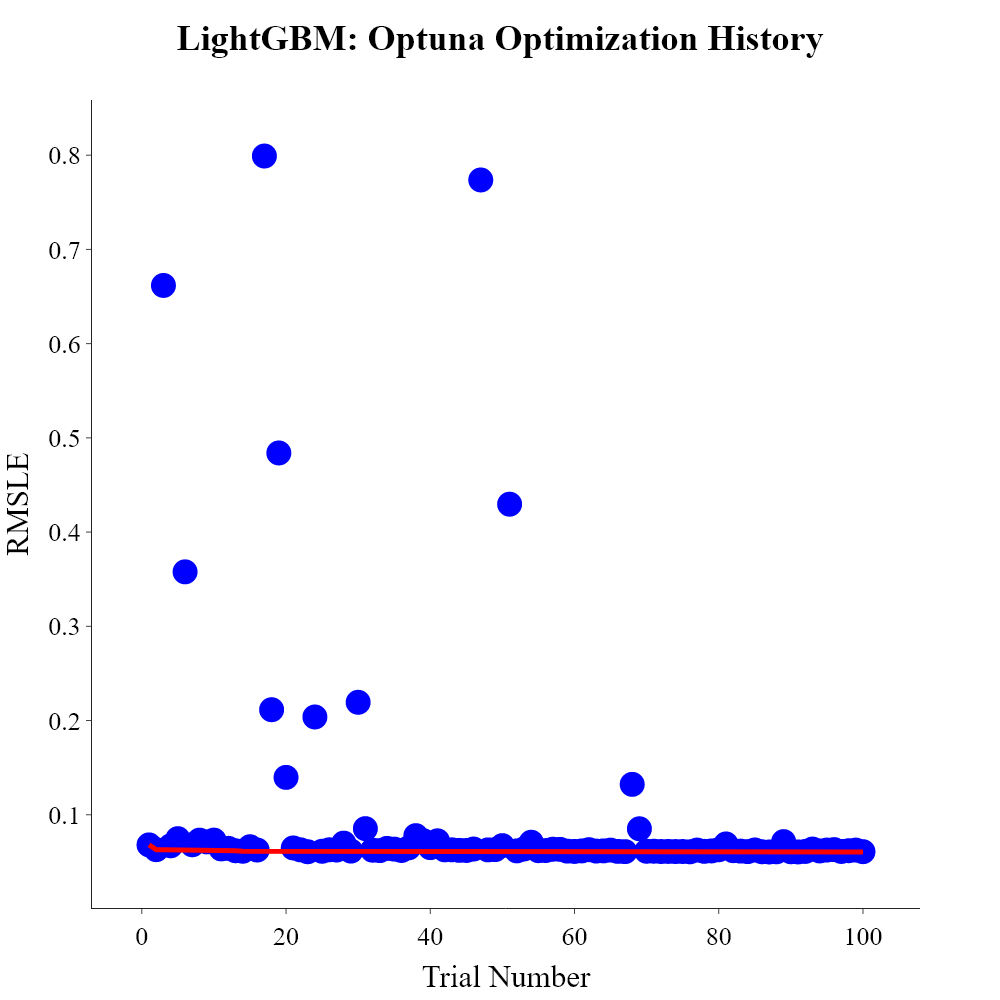

In [55]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>LightGBM: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

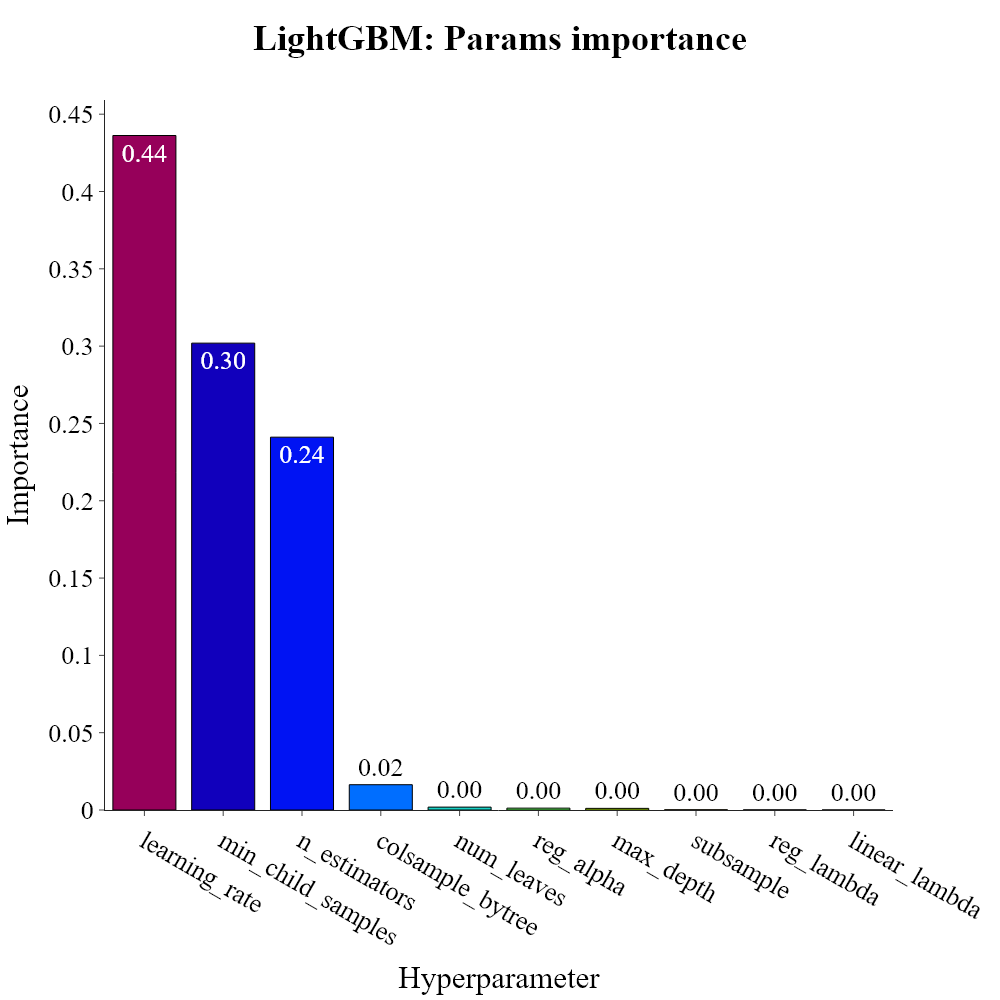

In [56]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>LightGBM: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [57]:
model = LGBMRegressor(**lgbm_best_params, random_state=SEED, n_jobs=-1, objective='regression', metric=compare_metric_name, linear_tree=True)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSLE: 0.0524 +- 0.0009
Validation RMSLE: 0.0605 +- 0.0028


### XGBoost

In [58]:
model = XGBRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)
params_grid = {
    "objective": ("constant", ["reg:squarederror"]),
    "seed": ("constant", [SEED]),
    "n_jobs": ("constant", [-1]),
    "booster": ("constant", ["gbtree"]),
    "tree_method": ("constant", ["hist"]),
    "enable_categorical": ("constant", [True]),
    "n_estimators": ("int", [50, 1000]),
    "max_depth": ("int", [3, 30]),
    "learning_rate": ("float", [1e-3, 0.5]),
    "subsample": ("float", [0.3, 1]),
    "colsample_bytree": ("float", [0.3, 1]),
    "colsample_bylevel": ("float", [0.3, 1]),
    "colsample_bynode": ("float", [0.3, 1]),
    "reg_alpha": ("float", [1e-3, 30]),
    "reg_lambda": ("float", [1e-3, 30]),
    "gamma": ("float", [1e-3, 30]),
    "tree_method": ("constant", ["hist"]),
}
study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
xgb_best_params = study.best_trial.params
print(xgb_best_params)

[I 2025-05-03 13:51:44,152] A new study created in memory with name: Optuna tuning
[I 2025-05-03 13:51:53,113] Trial 0 finished with value: 0.5675442099571228 and parameters: {'n_estimators': 330, 'max_depth': 17, 'learning_rate': 0.003287826254788394, 'subsample': 0.3255554040575356, 'colsample_bytree': 0.7737830722497602, 'colsample_bylevel': 0.6611562428979949, 'colsample_bynode': 0.6463494460474463, 'reg_alpha': 0.37761040255451583, 'reg_lambda': 0.0014958547068972478, 'gamma': 0.03999216300149093}. Best is trial 0 with value: 0.5675442099571228.
[I 2025-05-03 13:51:55,092] Trial 1 finished with value: 0.13530399054288864 and parameters: {'n_estimators': 949, 'max_depth': 4, 'learning_rate': 0.2147947785850581, 'subsample': 0.8626563515456908, 'colsample_bytree': 0.31907247004783607, 'colsample_bylevel': 0.6580472549057305, 'colsample_bynode': 0.5829352503057804, 'reg_alpha': 0.4733030314189369, 'reg_lambda': 0.1461558763011785, 'gamma': 0.01849150715170984}. Best is trial 1 with v

{'n_estimators': 503, 'max_depth': 8, 'learning_rate': 0.031173464405122368, 'subsample': 0.8253202649816548, 'colsample_bytree': 0.778579368799792, 'colsample_bylevel': 0.7968894901677881, 'colsample_bynode': 0.7404442704305852, 'reg_alpha': 0.7182446955073379, 'reg_lambda': 0.3077694201493285, 'gamma': 3.3065061438263776}


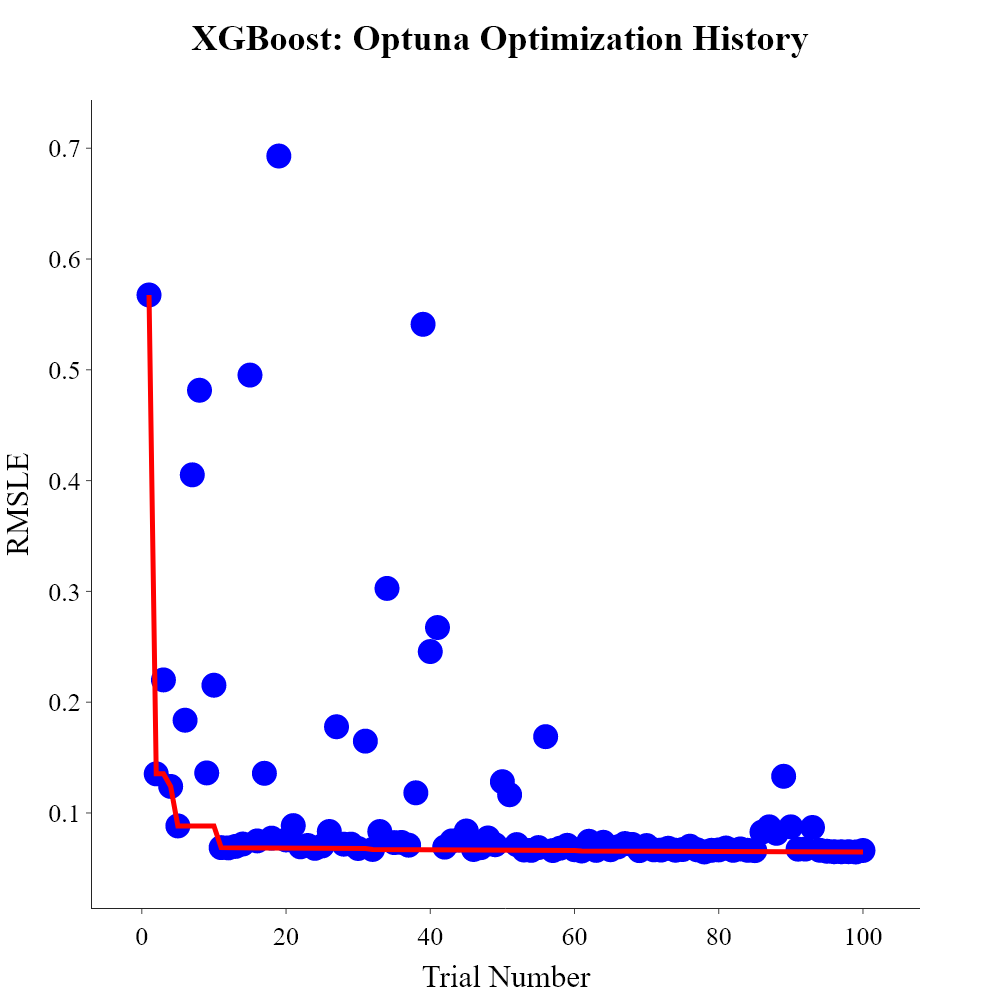

In [59]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>XGBoost: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

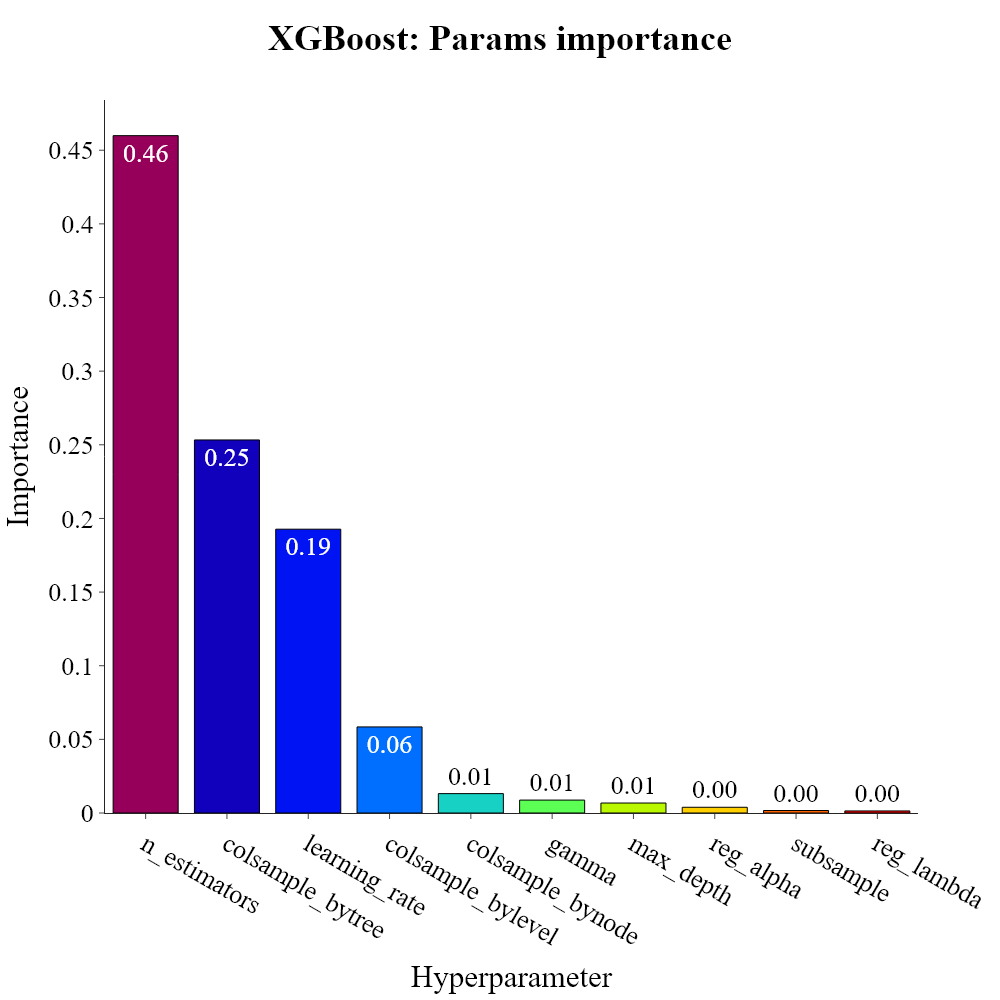

In [60]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>XGBoost: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [61]:
model = XGBRegressor(**xgb_best_params, random_state=SEED, n_jobs=-1, objective='reg:squarederror', enable_categorical=True, tree_method='hist')
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSLE: 0.0408 +- 0.0008
Validation RMSLE: 0.0648 +- 0.0029


### Histogram-based Gradient Boosting

In [62]:
model = HistGradientBoostingRegressor()
cv = RandomSearchCV(
    algorithm=model,
    metric=compare_metric_name,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_trials=N_TRIALS,
    seed=SEED
)

params_grid = {
    "random_state": ("constant", [SEED]),
    "loss": ("constant", ["squared_error"]),
    "categorical_features": ("constant", [categorical_features]),
    "learning_rate": ("float", [1e-3, 0.5]),
    "max_iter": ("int", [50, 1000]),
    "max_leaf_nodes": ("int", [10, 450]),
    "max_depth": ("int", [3, 30]),
    "min_samples_leaf": ("int", [10, 300]),
    "l2_regularization": ("float", [1e-3, 30]),
    "max_features": ("float", [0.3, 1]),
}
study = cv.tune(
    train_data[independent_features],
    train_data[target_feature],
    params_grid
)
hgbm_best_params = study.best_trial.params
print(hgbm_best_params)

[I 2025-05-03 14:00:52,116] A new study created in memory with name: Optuna tuning
[I 2025-05-03 14:00:54,709] Trial 0 finished with value: 0.16506074009597937 and parameters: {'learning_rate': 0.006241543527823154, 'max_iter': 554, 'max_leaf_nodes': 94, 'max_depth': 4, 'min_samples_leaf': 239, 'l2_regularization': 0.8679301209323235, 'max_features': 0.6463494460474463}. Best is trial 0 with value: 0.16506074009597937.
[I 2025-05-03 14:00:57,454] Trial 1 finished with value: 0.17852714217984694 and parameters: {'learning_rate': 0.03577131821038233, 'max_iter': 87, 'max_leaf_nodes': 167, 'max_depth': 29, 'min_samples_leaf': 27, 'l2_regularization': 7.386203463828322, 'max_features': 0.8626563515456908}. Best is trial 0 with value: 0.16506074009597937.
[I 2025-05-03 14:01:05,641] Trial 2 finished with value: 0.624121127530418 and parameters: {'learning_rate': 0.0013745804660383028, 'max_iter': 670, 'max_leaf_nodes': 253, 'max_depth': 19, 'min_samples_leaf': 150, 'l2_regularization': 0.01

{'learning_rate': 0.0208389751728405, 'max_iter': 452, 'max_leaf_nodes': 170, 'max_depth': 26, 'min_samples_leaf': 46, 'l2_regularization': 2.1575866425648953, 'max_features': 0.4877155892727267}


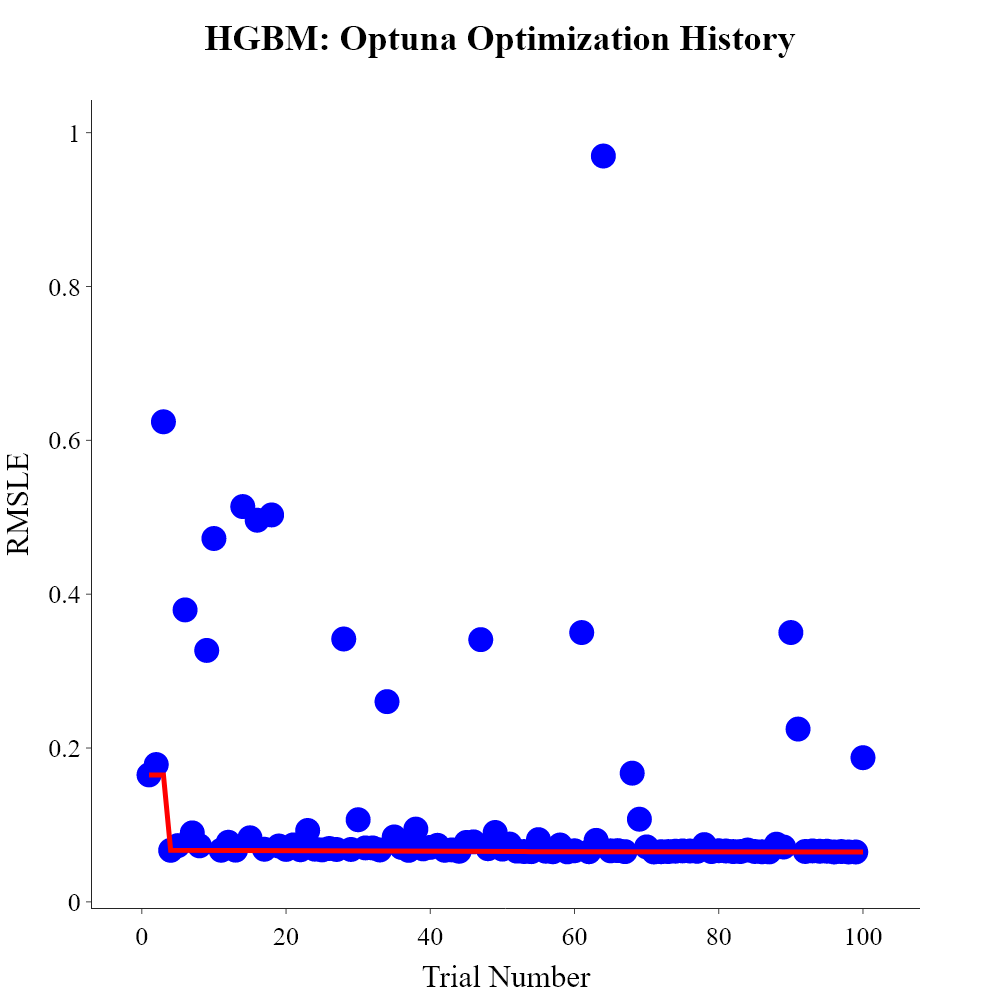

In [63]:
scores = study.trials_dataframe()
fig = go.Figure()
scores.index = scores.index + 1
fig.add_trace(go.Scatter(x=scores.index, y=scores["value"], mode="markers", name="Trial Score", marker=dict(size=25, color="blue"), showlegend=False))
minimum_scores = []
for i in range(len(scores)):
    minimum_scores.append(scores.loc[:i+1, "value"].min())
fig.add_trace(go.Scatter(x=scores.index, y=minimum_scores, mode="lines", name="Minimum Score", line=dict(color="red", width=5), showlegend=False))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>HGBM: Optuna Optimization History<b>", title_x=0.5, xaxis_title="Trial Number", yaxis_title=compare_metric_name, font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

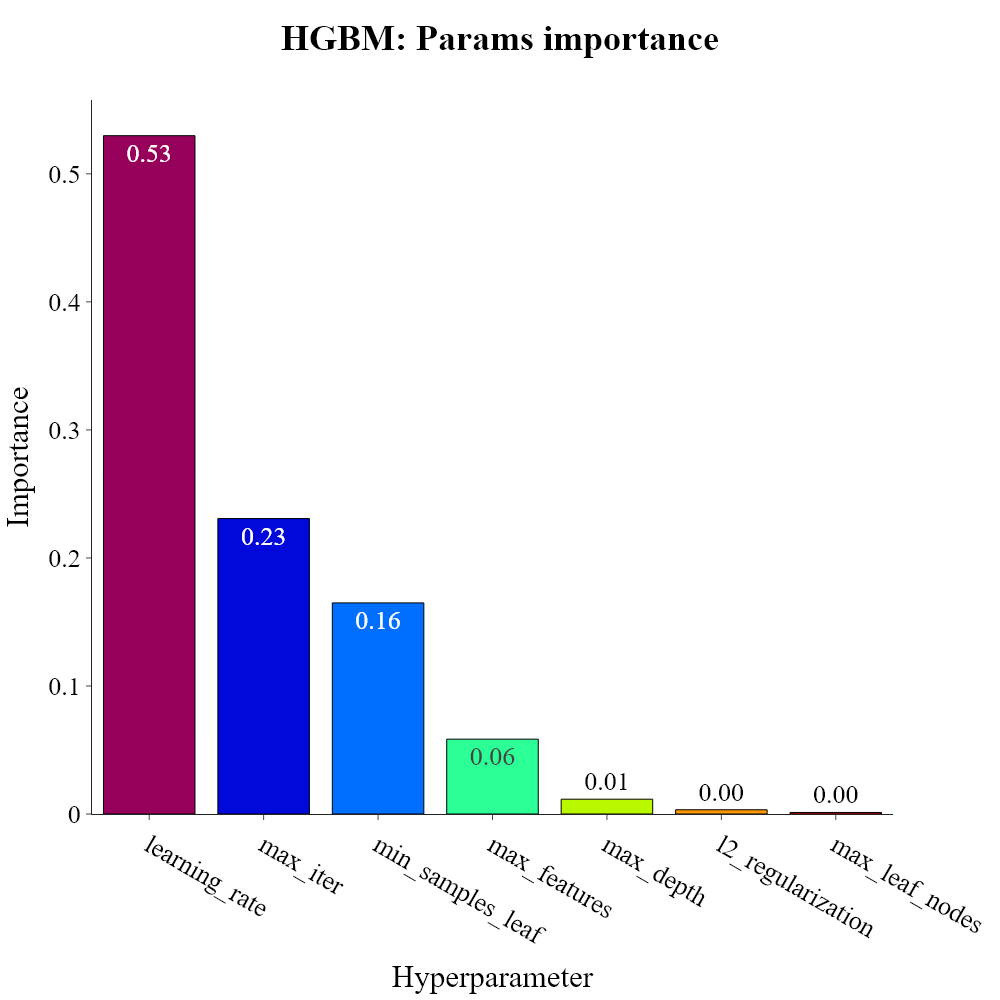

In [64]:
importances = optuna.importance.get_param_importances(study)
fig = go.Figure()
n_colors = len(importances)
colors = px.colors.sample_colorscale("rainbow", [n/(n_colors -1) for n in range(n_colors)])
fig.add_trace(go.Bar(x=list(importances.keys()), y=list(importances.values()), marker=dict(color=colors, line=dict(color='black', width=1), line_color='black'), text=[f"{v:.2f}" for v in list(importances.values())], textposition="auto"))
fig.update_layout(template="simple_white", width=1000, height=1000, title="<b>HGBM: Params importance<b>", title_x=0.5, xaxis_title="Hyperparameter", yaxis_title=f"Importance", font=dict(family="Times New Roman",size=26,color="Black"), showlegend=False)
fig.show("png")

In [65]:
model = HistGradientBoostingRegressor(**hgbm_best_params, random_state=SEED, categorical_features=categorical_features)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

Train RMSLE: 0.0483 +- 0.0005
Validation RMSLE: 0.0649 +- 0.0045


## Stacking

In [74]:
estimators = [
    ('lightgbm', LGBMRegressor(**lgbm_best_params, random_state=SEED, n_jobs=-1, verbose=-1, objective='regression', metric=compare_metric_name, linear_tree=True)),
    ('xgboost', XGBRegressor(**xgb_best_params, random_state=SEED, n_jobs=-1, objective='reg:squarederror', enable_categorical=True, tree_method='hist')),
    ('hist_gradient_boosting', HistGradientBoostingRegressor(**hgbm_best_params, random_state=SEED, categorical_features=categorical_features)),
]
stacking_model = StackingRegressor(estimators=estimators, final_estimator=ElasticNetCV(random_state=SEED), cv=KFold(n_splits=5, shuffle=True, random_state=SEED), n_jobs=-1)
train_scores, validation_scores = perform_cv(train_data[independent_features], train_data[target_feature], stacking_model, cv=KFold(n_splits=5, shuffle=True, random_state=SEED), metric_name=compare_metric_name)
print(f"Train {compare_metric_name}: {np.mean(train_scores):.4f} +- {np.std(train_scores):.4f}")
print(f"Validation {compare_metric_name}: {np.mean(validation_scores):.4f} +- {np.std(validation_scores):.4f}")

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.566e+03, tolerance: 3.081e+03

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.438e+03, tolerance: 3.110e+03

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.351e+03, tolerance: 3.085e+03

C:\Users\Kuba

Train RMSLE: 0.0459 +- 0.0005
Validation RMSLE: 0.0603 +- 0.0029


In [75]:
train_data_temp, test_data_temp = train_test_split(train_data, test_size=0.2, random_state=SEED, shuffle=True)
stacking_model.fit(train_data_temp[independent_features], train_data_temp[target_feature])
y_test = test_data_temp[target_feature]
y_test_pred = postprocess_predictions(stacking_model.predict(test_data_temp[independent_features]), min_value=1, max_value=314)

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.614e+03, tolerance: 3.081e+03



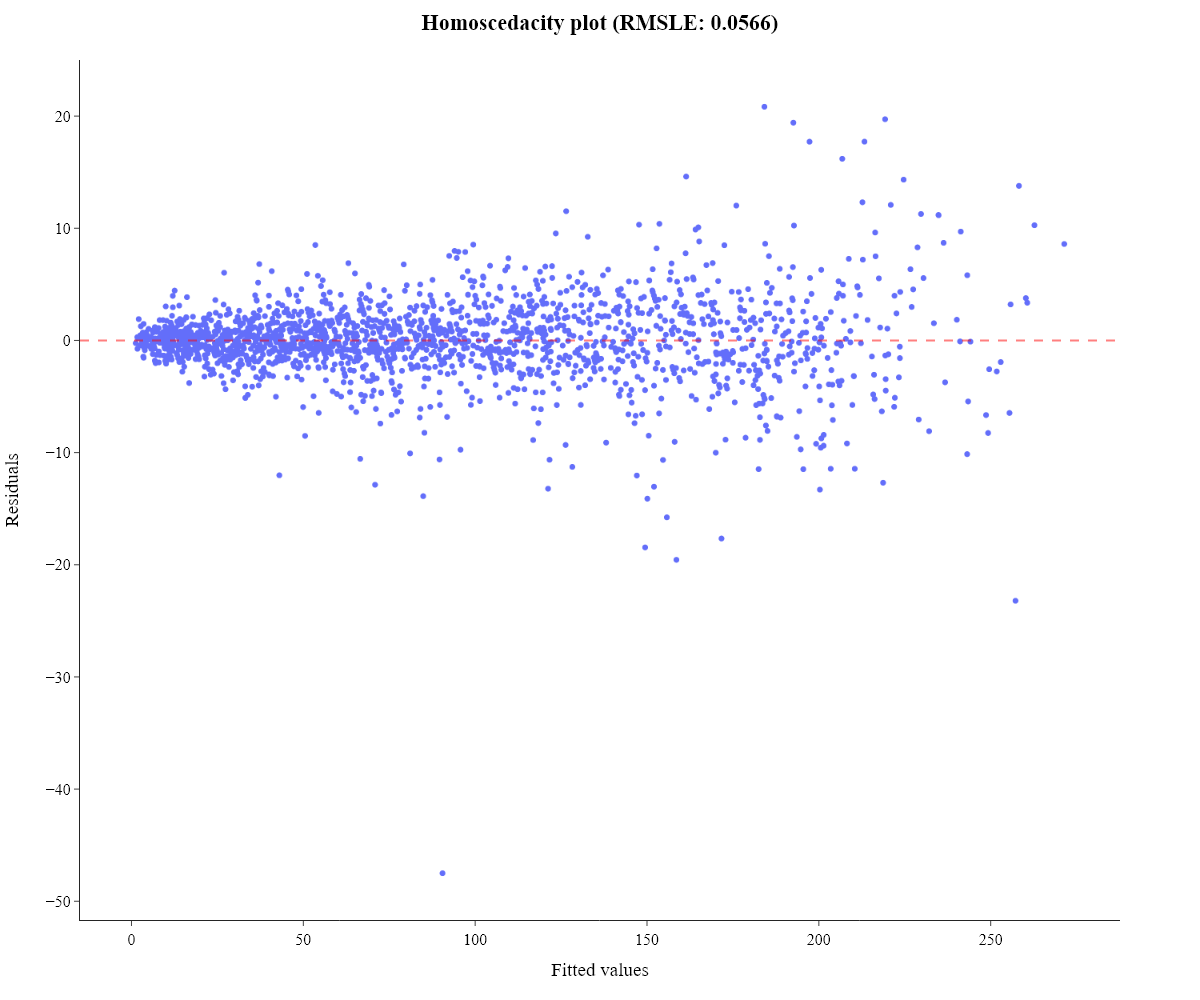

In [76]:
plots.homoscedacity_plot(y_test, y_test_pred, metric=compare_metric_name)

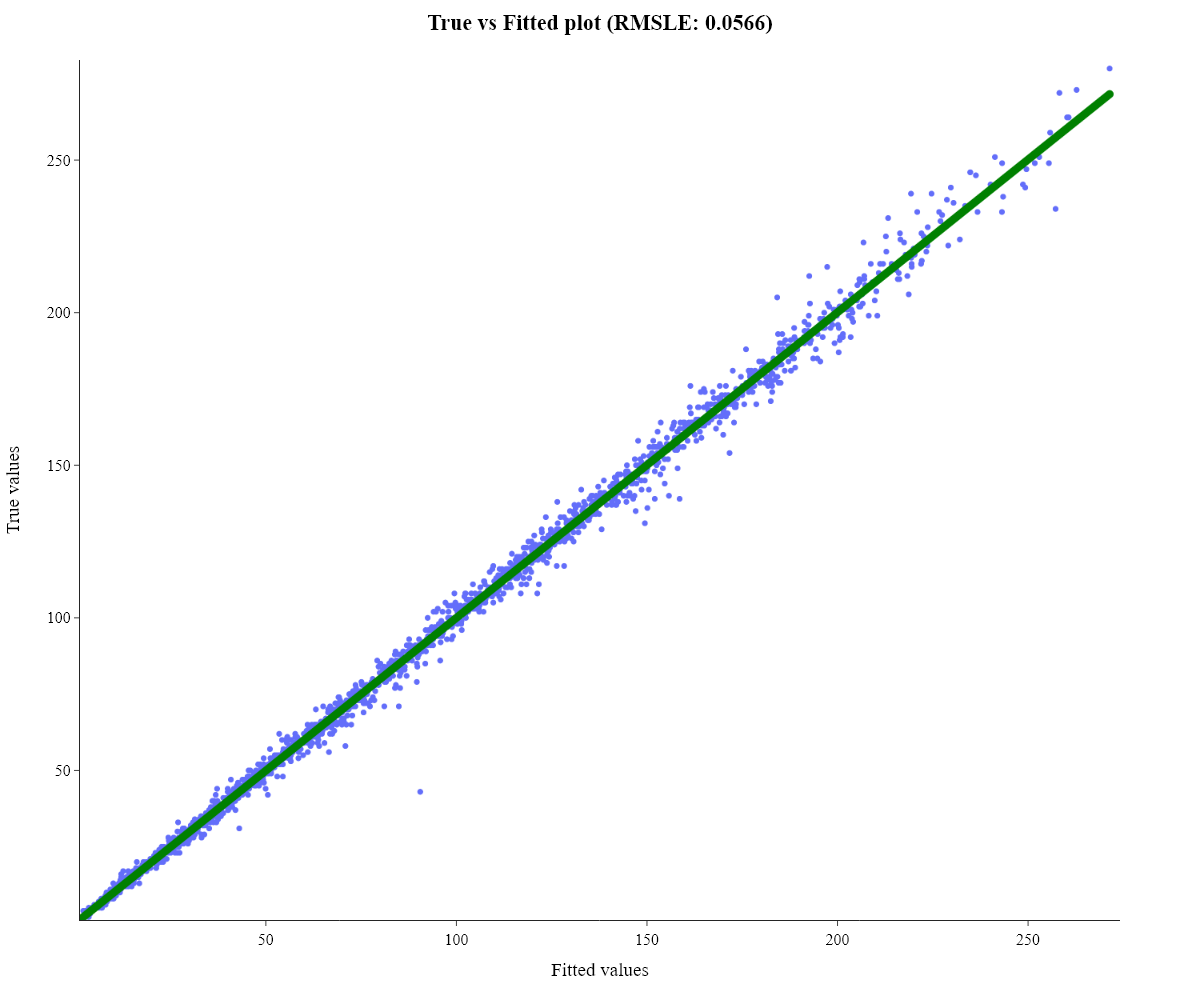

In [77]:
plots.true_vs_fitted_plot(y_test, y_test_pred, metric=compare_metric_name)

# Final submission

In [78]:
estimators = [
    ('lightgbm', LGBMRegressor(**lgbm_best_params, random_state=SEED, n_jobs=-1, verbose=-1, objective='regression', metric=compare_metric_name, linear_tree=True)),
    ('xgboost', XGBRegressor(**xgb_best_params, random_state=SEED, n_jobs=-1, objective='reg:squarederror', enable_categorical=True, tree_method='hist')),
    ('hist_gradient_boosting', HistGradientBoostingRegressor(**hgbm_best_params, random_state=SEED, categorical_features=categorical_features)),
]
final_model = StackingRegressor(estimators=estimators, final_estimator=ElasticNetCV(random_state=SEED), cv=KFold(n_splits=5, shuffle=True, random_state=SEED), n_jobs=-1)
final_model.fit(train_data.drop(target_feature, axis=1), train_data[target_feature])
submission = pd.read_csv("input/sample_submission.csv")
submission[target_feature] = postprocess_predictions(final_model.predict(test_data), min_value=1, max_value=314)
#submission.to_csv("submission.csv", index=False)
submission.head()

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.192e+03, tolerance: 3.870e+03



,id,Calories
0,750000,28.145359
1,750001,107.601060
2,750002,86.698773
3,750003,127.013979
4,750004,76.573423
